# 1. Setup e importación de datos

In [1]:
# Instalación de librerías necesarias
# pip install scikit-learn prince geopandas scipy matplotlib seaborn geopy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import requests
import random
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Prince (MCA)
import prince

# Scipy
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr
from scipy.spatial.distance import cdist

# Configuración general de los gráficos y de pandas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)

# Seed unificada para que el análisis sea reproducible entre corridas.
# Fijamos también las semillas globales de numpy y random, además de pasar
# SEED como random_state en cada modelo de sklearn.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

### 1.1 Carga del dataset enriquecido con coordenadas

Cargamos el dataset que ya viene con las coordenadas calculadas. Para cada propiedad agregamos la latitud, la longitud y la fuente que se usó para resolver la dirección. Las coordenadas surgen del consenso entre dos APIs oficiales argentinas que corrimos sobre las direcciones únicas de la base.

Hay un detalle importante: aproximadamente uno de cada siete avisos no tiene coordenadas. Esto pasa cuando el aviso no incluye calle y altura, o cuando la dirección quedó como texto libre (por ejemplo, descripciones del estilo "Venta departamento en Recoleta"). Esos avisos quedan en la base para los análisis que no necesitan geografía, pero los sacamos de cualquier cálculo de distancia o de agrupamiento espacial.

In [3]:
df = pd.read_csv('../data/geocoding/dataframe_con_coords.tsv', sep='\t', low_memory=False)

# Normalización de nombres de barrio para que coincidan con los del GeoJSON oficial.
# Las variantes habituales (Paternal con o sin "La", o con acentuación distinta) las unificamos
# acá para evitar que los joins espaciales pierdan registros. La forma canónica que usa
# el GeoJSON es la que ponemos como valor.
ALIAS_BARRIOS = {
    'La Paternal': 'Paternal',
    'LA PATERNAL': 'Paternal',
    'la paternal': 'Paternal',
    'PATERNAL': 'Paternal',
    'paternal': 'Paternal',
    'Boca': 'La Boca',
    'BOCA': 'La Boca',
    'la boca': 'La Boca',
    'LA BOCA': 'La Boca',
    'Núñez': 'Nuñez',
    'NUÑEZ': 'Nuñez',
    'nuñez': 'Nuñez',
    'NUNEZ': 'Nuñez',
    'Nunez': 'Nuñez',
}
df['barrio_oficial'] = df['barrio_oficial'].replace(ALIAS_BARRIOS)

print(f'Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas')
print(f'Con coordenadas: {df["lat"].notna().sum():,} '
      f'({100 * df["lat"].notna().mean():.1f} %)')
df.head()

Dataset cargado: 51,996 filas y 51 columnas
Con coordenadas: 44,142 (84.9 %)


,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_oficial,moneda,accesible_movilidad_reducida,acepta_caucion,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,dependencia_servicio,dormitorios,expensas_incluidas_en_precio,gimnasio,lavadero,m2_total,ofrece_financiacion,parrilla,pileta,portero,sum,terraza,tiene_expensas,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count,m2_relativo_barrio,lat,lon,geo_source
0,58757240,zonaprop,alquiler,"750,000.000",Mansilla,"2,936.000",0,0,0,0,0,1,0,Recoleta,ars,0,0,0,2.000,36.000,0,0,1,0,1.000,0,1.000,False,0,1,60.000,0,0,0,0,0,1,1.000,"300,000.000",0,"12,500.000",estandar,estandar,13.528,4.111,9.434,5.000,NaN,-34.595,-58.408,consenso_multi_api
1,58818211,zonaprop,alquiler,"1,700,000.000",Cespedes,"2,300.000",0,0,0,1,0,0,0,Belgrano,ars,0,1,0,3.000,35.000,0,0,1,0,2.000,0,2.000,False,0,1,114.000,0,1,0,0,0,1,1.000,"400,000.000",0,"14,912.281",estandar,estandar,14.346,4.745,9.610,7.000,NaN,-34.568,-58.447,consenso_multi_api
2,58564550,zonaprop,alquiler,"2,500.000",Riobamba,"1,200.000",0,0,0,1,1,1,0,Recoleta,usd,0,0,0,4.000,48.500,0,0,1,0,2.000,0,2.000,False,1,1,121.000,0,1,1,0,0,0,1.000,"1,150,000.000",0,20.661,estandar,estandar,7.824,4.804,3.076,9.000,NaN,-34.595,-58.395,consenso_multi_api
3,58314210,zonaprop,alquiler,"1,300.000",Pereyra Lucena,"2,500.000",0,0,0,1,0,1,1,Palermo,usd,0,0,0,2.000,20.000,1,0,1,0,1.000,0,1.000,False,0,0,66.000,0,0,0,0,0,1,1.000,"384,500.000",0,19.697,estandar,estandar,7.171,4.205,3.030,7.000,NaN,NaN,NaN,consenso_multi_api
4,58810878,zonaprop,alquiler,"3,800.000",Lola Mora,400.000,0,0,0,1,1,0,0,Puerto Madero,usd,0,0,0,3.000,14.000,0,0,0,0,2.000,0,2.000,False,1,0,117.000,0,0,1,0,0,0,1.000,"507,000.000",0,32.479,premium,premium,8.243,4.771,3.511,5.000,NaN,NaN,NaN,consenso_multi_api


In [4]:
# Revisamos rápidamente las columnas y la distribución por tipo de operación
print('Columnas disponibles:')
print(df.columns.tolist())
print('\nDistribución por operación:')
print(df['operacion'].value_counts())

Columnas disponibles:
['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'ambientes', 'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2', 'amenities_count', 'm2_relativo_barrio', 'lat', 'lon', 'geo_source']

Distribución por operación:
operacion
venta                28643
alquiler             18220
alquiler_temporal     5133
Name: count, dtype: int64


También importamos los KPIs calculados en `04_kpi_pipeline.ipynb`.

In [5]:
# Cargamos el dataframe de KPIs ya consolidado por el pipeline
df_kpis = pd.read_csv('../data/processed/dataframe_kpis.tsv', sep='\t')
print(f'Dataset cargado: {df_kpis.shape[0]:,} filas y {df_kpis.shape[1]} columnas')
df_kpis.head()

Dataset cargado: 48 filas y 22 columnas


,barrio_oficial,venta_mediana,alquiler_mediano,expensas_medianas,tarifa_mensual_mediana,precio_m2_mediano,rent_bruta_lp_pct,rent_neta_lp_pct,rent_bruta_temp_pct,rent_neta_temp_pct,años_recupero,retorno_neto_lp_mediano,retorno_neto_temp_mediano,ingreso_anual_mediano,costo_propietario_mediano,costo_expensas_pct,indice_bruto,indice_neto,modalidad_optima_bruta,modalidad_optima_neta,n_lp,n_temp
0,Villa Luro,"119,450.000",494.700,91.873,"1,300.000","2,414.286",4.970,5,9.530,9.000,20.100,"5,936.396","10,158.318","11,388.000","1,229.682",1.000,1.920,1.800,Temporario,Temporario,157,2.000
1,Nueva Pompeya,"75,000.000",494.700,70.671,925.000,"1,333.333",7.920,7,10.800,9.000,12.600,"5,512.367","6,958.124","8,103.000","1,144.876",2.000,1.360,1.290,Temporario,Temporario,17,2.000
2,Parque Avellaneda,"78,000.000",459.364,77.739,"1,000.000","1,612.903",7.070,7,11.230,7.000,14.100,"5,512.367","5,791.802","8,760.000","2,968.198",4.000,1.590,1.000,Temporario,Largo plazo,40,1.000
3,La Boca,"73,640.000",416.961,100.707,600.000,"1,393.023",6.790,7,7.140,6.000,14.700,"5,003.534","4,323.138","5,256.000","1,017.668",1.000,1.050,0.860,Temporario,Largo plazo,70,4.000
4,Monserrat,"87,000.000",500.000,134.276,600.000,"1,828.571",6.900,7,6.040,5.000,14.500,"6,000.000","4,139.555","5,256.000","1,526.502",2.000,0.880,0.710,Largo plazo,Largo plazo,329,123.000


In [6]:
df_kpis = pd.read_csv('../data/raw/dataframe_kpis.tsv', sep='\t')
print(f'Dataset cargado: {df_kpis.shape[0]:,} filas y {df_kpis.shape[1]} columnas')
df_kpis.head()

Dataset cargado: 48 filas y 18 columnas


,barrio_oficial,rent_bruta_lp_pct,años_recupero,precio_m2_mediano,precio_m2_promedio,retorno_neto_lp_mediano,rent_neta_lp_pct,m2_relativo_barrio_mediano,rent_bruta_temp_pct,indice_bruto,modalidad_optima_bruta,ingreso_anual_mediano,costo_propietario_mediano,retorno_neto_temp_mediano,costo_expensas_pct,rent_neta_temp_pct,indice_neto,modalidad_optima_neta
0,Agronomia,5.140,19.500,"2,375.000","2,452.000","5,088.339",5,1.000,5.310,1.030,Temporario,"5,256.000","1,187.279","4,068.721",1.000,4.000,0.800,Largo plazo
1,Almagro,4.550,22.000,"2,297.000","2,352.000","5,681.979",5,1.000,4.560,1.000,Temporario,"5,694.000","1,187.279","4,407.943",1.000,4.000,0.800,Largo plazo
2,Balvanera,6.120,16.300,"1,645.000","1,731.000","5,512.367",6,1.000,5.570,0.910,Largo plazo,"5,014.558","1,297.527","3,559.887",1.000,4.000,0.670,Largo plazo
3,Barracas,5.300,18.900,"2,091.000","2,160.000","6,614.841",5,1.000,4.960,0.940,Largo plazo,"6,190.813","1,653.710","4,690.304",1.000,4.000,0.800,Largo plazo
4,Belgrano,4.240,23.600,"3,112.000","3,351.000","9,328.622",4,1.000,3.240,0.760,Largo plazo,"7,119.435","1,526.502","5,502.700",1.000,3.000,0.750,Largo plazo


In [7]:
df_kpis.columns

Index(['barrio_oficial', 'rent_bruta_lp_pct', 'años_recupero',
       'precio_m2_mediano', 'precio_m2_promedio', 'retorno_neto_lp_mediano',
       'rent_neta_lp_pct', 'm2_relativo_barrio_mediano', 'rent_bruta_temp_pct',
       'indice_bruto', 'modalidad_optima_bruta', 'ingreso_anual_mediano',
       'costo_propietario_mediano', 'retorno_neto_temp_mediano',
       'costo_expensas_pct', 'rent_neta_temp_pct', 'indice_neto',
       'modalidad_optima_neta'],
      dtype='object')

### 1.2 Preparación para análisis

Aunque al principio nos resultaron útiles, decidimos descartar las pocas ventas que están publicadas en pesos. Aún convirtiéndolas a dólares quedaban en valores muy bajos por las condiciones particulares de esas propiedades (en general en mal estado), y nos generaban ruido en las conclusiones.

In [8]:
df = df[~((df['operacion'] == 'venta') & (df['moneda'] == 'ars'))]

In [9]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count        mean      median         std  \
moneda operacion                                                      
ars    alquiler           12339 803,925.003 700,000.000 359,879.307   
       alquiler_temporal    459 784,724.887 750,000.000 253,418.624   
usd    alquiler            5881   1,713.305   1,200.000   1,431.851   
       alquiler_temporal   4674   1,052.809     800.000     667.782   
       venta              28639 237,102.007 145,000.000 346,399.372   

                                 min           max  
moneda operacion                                    
ars    alquiler          115,000.000 4,500,000.000  
       alquiler_temporal 120,000.000 2,000,000.000  
usd    alquiler              300.000    10,000.000  
       alquiler_temporal     250.000     5,000.000  
       venta              24,000.000 9,500,000.000

Para poder comparar todos los precios entre sí, sumamos una columna con los valores convertidos a dólares.

In [10]:
import json
from datetime import date
from pathlib import Path

# Cache del tipo de cambio: si ya está guardado lo reutilizamos, si no lo
# bajamos del BCRA y lo persistimos. Esto hace que las conversiones a dólares
# sean reproducibles entre corridas, incluso si el tipo de cambio del día cambia.

CACHE_TC = Path('../data/processed/tipo_cambio_cache.json')
CACHE_TC.parent.mkdir(parents=True, exist_ok=True)

def obtener_dolar_oficial(cache_path=CACHE_TC):
    if cache_path.exists():
        try:
            data = json.loads(cache_path.read_text(encoding='utf-8'))
            tc = data['tipo_cambio']
            fecha = data['fecha']
            print(f'Tipo de cambio leído desde cache (fecha: {fecha}): $ {tc:,.2f} ARS/USD')
            return tc
        except Exception as e:
            print(f'Cache de tipo de cambio inválido, se vuelve a descargar: {e}')

    hoy = date.today().strftime('%Y-%m-%d')
    try:
        url = 'https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc'
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        cache_path.write_text(
            json.dumps({'tipo_cambio': tc, 'fecha': hoy}, ensure_ascii=False, indent=2),
            encoding='utf-8'
        )
        print(f'Tipo de cambio descargado y cacheado al {hoy}: $ {tc:,.2f} ARS/USD')
        return tc
    except Exception as e:
        print(f'No se pudo obtener el tipo de cambio del BCRA: {e}')
        print('Ingresalo manualmente en la siguiente línea.')
        return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

df['precio_usd'] = df.apply(
    lambda row: row['precio'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio'],
    axis=1
)
df['precio_por_m2_usd'] = df.apply(
    lambda row: row['precio_por_m2'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio_por_m2'],
    axis=1
)
print('Precios convertidos a dólares usando el tipo de cambio cacheado.')

Tipo de cambio descargado y cacheado al 2026-06-23: $ 1,460.00 ARS/USD
Precios convertidos a dólares usando el tipo de cambio cacheado.


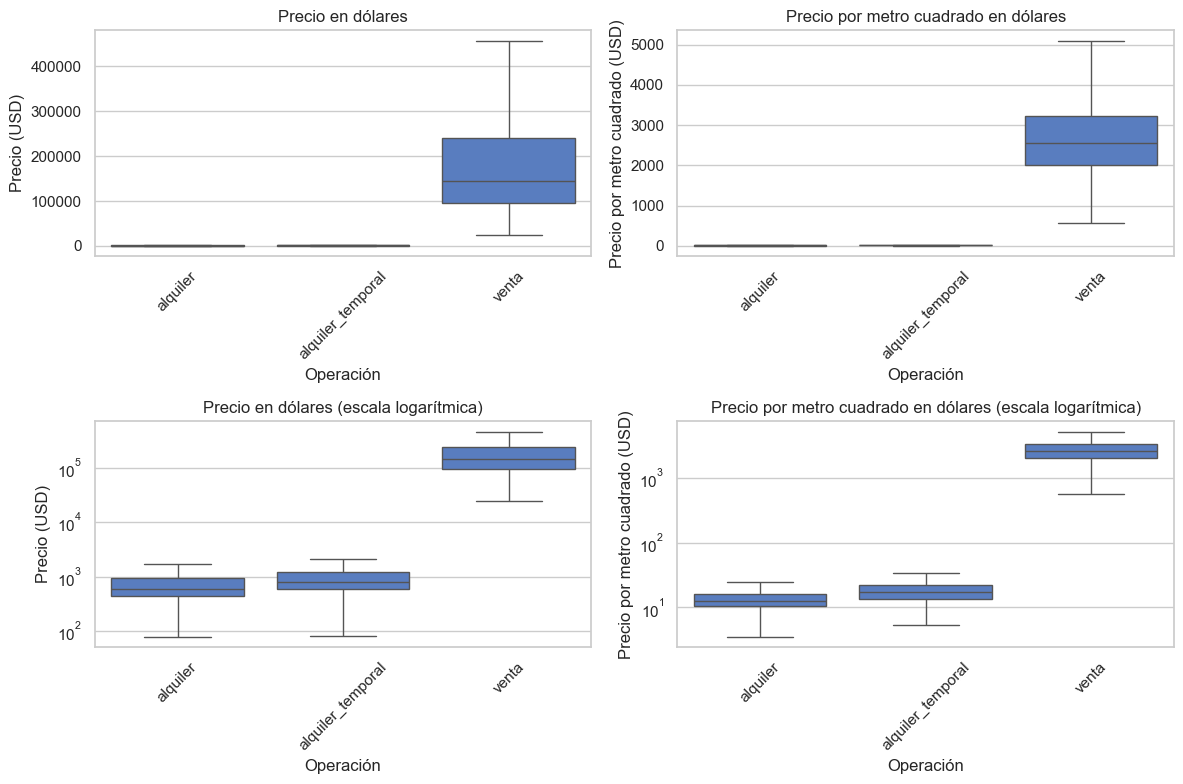

In [11]:
df_box_precio = df.dropna(subset=["operacion", "precio_usd"]).copy()
df_box_m2 = df.dropna(subset=["operacion", "precio_por_m2_usd"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Precio en dólares
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title("Precio en dólares")
axes[0, 0].set_xlabel("Operación")
axes[0, 0].set_ylabel("Precio (USD)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Precio por metro cuadrado en dólares
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Precio por metro cuadrado en dólares")
axes[0, 1].set_xlabel("Operación")
axes[0, 1].set_ylabel("Precio por metro cuadrado (USD)")
axes[0, 1].tick_params(axis="x", rotation=45)

# Precio en dólares, escala logarítmica
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Precio en dólares (escala logarítmica)")
axes[1, 0].set_xlabel("Operación")
axes[1, 0].set_ylabel("Precio (USD)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Precio por metro cuadrado en dólares, escala logarítmica
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Precio por metro cuadrado en dólares (escala logarítmica)")
axes[1, 1].set_xlabel("Operación")
axes[1, 1].set_ylabel("Precio por metro cuadrado (USD)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 2. Enriquecimiento espacial

Esto nos sirve para testear la hipótesis de que la cercanía al subte impacta en el precio del metro cuadrado, y también lo aprovechamos más adelante en el clustering y en los modelos.

Como ya mencionamos, las propiedades que no tienen coordenadas no entran en ninguno de los cálculos espaciales. Sí las seguimos usando para los análisis que no dependen de la ubicación.

### 2.1 Descarga de fuentes exógenas

Arrancamos bajando las coordenadas de las estaciones de subte para poder medir qué tan cerca está cada propiedad de la red.

In [12]:
URL_SUBTE = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/'
    'subte-estaciones/estaciones-de-subte.csv'
)

subte = pd.read_csv(URL_SUBTE, sep=';')
print('Columnas del CSV de subte:', subte.columns.tolist())
subte.head(3)

Columnas del CSV de subte: ['long', 'lat', 'id', 'estacion', 'linea']


,long,lat,id,estacion,linea
0,"-58,39892759","-34,63575018",1,CASEROS,H
1,"-58,40096956","-34,62937566",2,INCLAN - MEZQUITA AL AHMAD,H
2,"-58,40232273","-34,62309232",3,HUMBERTO 1Â°,H


In [13]:
subte.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   long      90 non-null     object
 1   lat       90 non-null     object
 2   id        90 non-null     int64 
 3   estacion  90 non-null     object
 4   linea     90 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.6+ KB


In [14]:
col_map = {}
for col in subte.columns:
    cl = col.lower()
    if 'lat' in cl:
        col_map[col] = 'lat_subte'
    elif 'long' in cl:
        col_map[col] = 'lon_subte'
    elif 'nombre' in cl or 'estacion' in cl or 'station' in cl:
        col_map[col] = 'nombre_estacion'
    elif 'linea' in cl or 'line' in cl:
        col_map[col] = 'linea'

subte = subte.rename(columns=col_map)
subte = subte[['lon_subte', 'lat_subte']].dropna()
# En el archivo original las comas hacen de separador decimal, las cambiamos por punto
subte['lat_subte'] = subte['lat_subte'].str.replace(',', '.', regex=False)
subte['lon_subte'] = subte['lon_subte'].str.replace(',', '.', regex=False)
subte['lat_subte'] = pd.to_numeric(subte['lat_subte'])
subte['lon_subte'] = pd.to_numeric(subte['lon_subte'])
subte = subte.dropna()
print(f'Estaciones de subte disponibles: {len(subte)}')
subte.head()

Estaciones de subte disponibles: 90


,lon_subte,lat_subte
0,-58.399,-34.636
1,-58.401,-34.629
2,-58.402,-34.623
3,-58.405,-34.615
4,-58.406,-34.609


### 2.2 Cobertura del geocoding por barrio

Antes de seguir, revisamos qué tan bien resolvieron las coordenadas en cada barrio. Esto nos sirve para tener en mente dónde puede haber sesgo por menor cobertura.

In [15]:
# Cuántas propiedades quedaron con coordenadas usables
mask_geo = df['lat'].notna() & df['lon'].notna()
print(f'Total de avisos:                   {len(df):>7,}')
print(f'Con coordenadas (uso geográfico):  {mask_geo.sum():>7,}  ({100*mask_geo.mean():.1f} %)')
print(f'Sin coordenadas (quedan fuera):    {(~mask_geo).sum():>7,}')

cob = (df.groupby('barrio_oficial')
         .agg(total=('lat', 'size'), con_coords=('lat', 'count'))
         .assign(cobertura_pct=lambda x: (100 * x['con_coords'] / x['total']).round(1)))

print('\nBarrios con menor cobertura, donde más avisos quedaron sin coordenadas:')
print(cob.sort_values('cobertura_pct').head(5).to_string())
print('\nBarrios con mejor cobertura:')
print(cob.sort_values('cobertura_pct', ascending=False).head(5).to_string())

Total de avisos:                    51,992
Con coordenadas (uso geográfico):   44,138  (84.9 %)
Sin coordenadas (quedan fuera):      7,854

Barrios con menor cobertura, donde más avisos quedaron sin coordenadas:
                   total  con_coords  cobertura_pct
barrio_oficial                                     
Puerto Madero       1764        1201         68.100
Villa Lugano         276         199         72.100
Villa Soldati         20          15         75.000
Agronomia             70          53         75.700
Parque Avellaneda    118          91         77.100

Barrios con mejor cobertura:
                total  con_coords  cobertura_pct
barrio_oficial                                  
Villa Ortuzar     220         210         95.500
Constitucion      259         246         95.000
San Cristobal     714         670         93.800
Coghlan           369         338         91.600
Mataderos         248         227         91.500


Como podemos ver, en general obtuvimos una gran cantidad de cobertura de coordenadas. Puerto Madero es el barrio con menor cobertura (68%). Consecuentemente, consideramos que tenemos suficientes coordenadas para realizar análisis de distancias robustas.

In [16]:
# Bajamos el GeoJSON con los polígonos de los barrios de CABA
URL_GEOJSON = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/'
    'ministerio-de-educacion/barrios/barrios.geojson'
)
gdf_barrios = gpd.read_file(URL_GEOJSON)

# Normalizamos el nombre de la columna que tiene el barrio
for col in gdf_barrios.columns:
    if 'nombre' in col.lower():
        gdf_barrios = gdf_barrios.rename(columns={col: 'barrio_oficial'})
        break

# Calculamos el centroide de cada barrio
gdf_barrios = gdf_barrios.set_crs('EPSG:4326', allow_override=True)
gdf_barrios['centroid'] = gdf_barrios.geometry.centroid
gdf_barrios['lat_barrio'] = gdf_barrios['centroid'].y
gdf_barrios['lon_barrio'] = gdf_barrios['centroid'].x

centroides = gdf_barrios[['barrio_oficial', 'lat_barrio', 'lon_barrio']].copy()
print(f'Barrios con centroide calculado: {len(centroides)}')
centroides.head()

Barrios con centroide calculado: 48


,barrio_oficial,lat_barrio,lon_barrio
0,Agronomia,-34.593,-58.489
1,Almagro,-34.609,-58.422
2,Balvanera,-34.609,-58.403
3,Barracas,-34.646,-58.384
4,Belgrano,-34.555,-58.450


### 2.3 Cálculo de distancia al subte más cercano

Usamos la distancia euclidiana en grados como aproximación, corregida por el factor de latitud. Para la ciudad de Buenos Aires un grado de latitud equivale a unos 111 kilómetros, y un grado de longitud a unos 91. Con esa conversión simple podemos pasar los grados a kilómetros sin complicarnos.

In [17]:
def distancia_min_subte_km(lat, lon, subte_coords):
    """Distancia en kilómetros al subte más cercano para un punto.
    Es una aproximación euclidiana corregida por latitud, válida
    para distancias cortas dentro de la ciudad."""
    LAT_KM = 111.0
    LON_KM = 111.0 * np.cos(np.radians(lat))
    dlat = (subte_coords[:, 0] - lat) * LAT_KM
    dlon = (subte_coords[:, 1] - lon) * LON_KM
    return np.sqrt(dlat ** 2 + dlon ** 2).min()


def distancia_min_subte_km_vec(lats, lons, subte_coords):
    """Versión vectorizada. Recibe arrays de latitudes y longitudes
    y devuelve un array con las distancias mínimas. Donde la coordenada
    de entrada es nula, devuelve nulo."""
    lats = np.asarray(lats, dtype=float)
    lons = np.asarray(lons, dtype=float)
    out = np.full(len(lats), np.nan)
    valid = ~(np.isnan(lats) | np.isnan(lons))
    if not valid.any():
        return out
    lv, ov = lats[valid], lons[valid]
    lat_km = 111.0
    lon_km = 111.0 * np.cos(np.radians(lv[:, None]))
    dlat = (subte_coords[:, 0][None, :] - lv[:, None]) * lat_km
    dlon = (subte_coords[:, 1][None, :] - ov[:, None]) * lon_km
    out[valid] = np.sqrt(dlat ** 2 + dlon ** 2).min(axis=1)
    return out


subte_coords = subte[['lat_subte', 'lon_subte']].values

# También calculamos la distancia desde el centroide de cada barrio,
# que nos sirve como referencia y para los mapas coropléticos
centroides['dist_subte_km_centroide'] = centroides.apply(
    lambda row: distancia_min_subte_km(row['lat_barrio'], row['lon_barrio'], subte_coords),
    axis=1
)
print('Distancia desde el centroide al subte más cercano, por barrio. Los más cercanos y los más lejanos:')
ordenado = centroides[['barrio_oficial', 'dist_subte_km_centroide']].sort_values('dist_subte_km_centroide')
print(pd.concat([ordenado.head(5), ordenado.tail(5)]).to_string(index=False))

Distancia desde el centroide al subte más cercano, por barrio. Los más cercanos y los más lejanos:
 barrio_oficial  dist_subte_km_centroide
    San Nicolas                    0.018
      Monserrat                    0.073
  San Cristobal                    0.094
      Chacarita                    0.151
      Balvanera                    0.188
      Mataderos                    4.023
        Liniers                    4.747
      Versalles                    4.821
     Villa Real                    5.300
Villa Riachuelo                    5.391


In [18]:
# Calculamos la distancia al subte para cada propiedad
df['dist_subte_km'] = distancia_min_subte_km_vec(df['lat'].values, df['lon'].values, subte_coords)

# Sumamos las coordenadas del centroide del barrio, que después usamos en algunos mapas
df = df.merge(centroides[['barrio_oficial', 'lat_barrio', 'lon_barrio']],
              on='barrio_oficial', how='left')

mask = df['dist_subte_km'].notna()
print(f'Propiedades con distancia al subte calculada: {mask.sum():,} de {len(df):,} '
      f'({100*mask.mean():.1f} %)')
print(f'Excluidas del análisis geográfico (sin coordenadas): {(~mask).sum():,}')
print('\nEstadísticas de la distancia al subte en kilómetros, solo para las propiedades con coordenadas:')
print(df['dist_subte_km'].describe())

Propiedades con distancia al subte calculada: 44,138 de 51,992 (84.9 %)
Excluidas del análisis geográfico (sin coordenadas): 7,854

Estadísticas de la distancia al subte en kilómetros, solo para las propiedades con coordenadas:
count   44,138.000
mean         0.846
std          0.939
min          0.001
25%          0.303
50%          0.533
75%          0.929
max          5.794
Name: dist_subte_km, dtype: float64


### 2.4 Visualización espacial: precio por metro cuadrado y distancia al subte

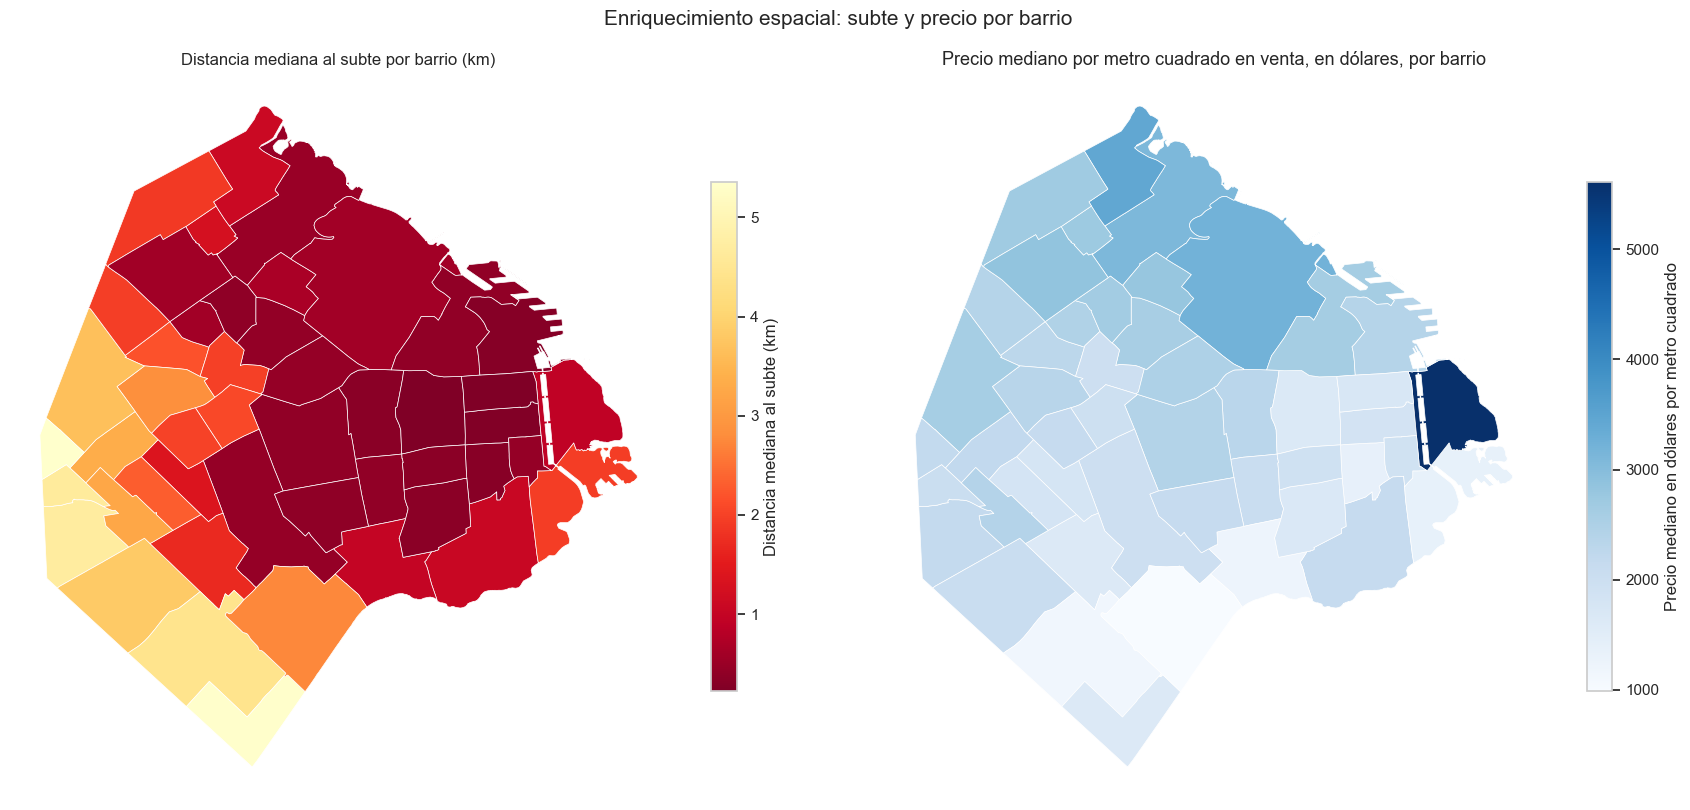

In [19]:
# Mapa coroplético. Para cada barrio se colorea con la mediana
# de las distancias calculadas a nivel propiedad.
dist_barrio = df.groupby('barrio_oficial')['dist_subte_km'].median()

gdf_mapa = gdf_barrios.copy()
gdf_mapa['dist_subte_km'] = gdf_mapa['barrio_oficial'].map(dist_barrio)

# Precio mediano por metro cuadrado en ventas en dólares, por barrio.
# Filtramos las propiedades sin coordenadas para mantener consistencia.
precio_barrio = (
    df[(df['operacion'] == 'venta') & (df['moneda'] == 'usd') & df['lat'].notna()]
    .groupby('barrio_oficial')['precio_por_m2']
    .median()
)
gdf_mapa['precio_m2_mediano'] = gdf_mapa['barrio_oficial'].map(precio_barrio)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf_mapa.plot(
    column='dist_subte_km', cmap='YlOrRd_r', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Distancia mediana al subte (km)', 'shrink': 0.7}
)
axes[0].set_title('Distancia mediana al subte por barrio (km)', fontsize=12)
axes[0].axis('off')

gdf_mapa.plot(
    column='precio_m2_mediano', cmap='Blues', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Precio mediano en dólares por metro cuadrado', 'shrink': 0.7}
)
axes[1].set_title('Precio mediano por metro cuadrado en venta, en dólares, por barrio', fontsize=13)
axes[1].axis('off')

plt.suptitle('Enriquecimiento espacial: subte y precio por barrio', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Otras distancias geográficas

Sumamos otras distancias para enriquecer cada propiedad. La distancia al espacio verde más cercano sirve como proxy de calidad ambiental y suele influir en el valor. La distancia a la estación de tren más cercana captura la accesibilidad por fuera del subte, sobre todo en los barrios del sur y el oeste donde la red de subte llega poco.

Todas se calculan con la misma aproximación euclidiana corregida por latitud que usamos para el subte, y solo aplican a las propiedades que tienen coordenadas resueltas.

In [20]:
import re

# Espacios Verdes
URL_VERDES = (
    'https://data.buenosaires.gob.ar/dataset/espacios-verdes'
    '/resource/2a9af960-02a3-44bb-b57e-0a8295f6e0e2/download'
)
try:
    verdes = gpd.read_file(URL_VERDES)
    verdes = verdes.to_crs('EPSG:4326')
    verdes_centroides = verdes.geometry.centroid
    verdes_coords = np.array([(g.y, g.x) for g in verdes_centroides])
    df['dist_verde_km'] = distancia_min_subte_km_vec(
        df['lat'].values, df['lon'].values, verdes_coords
    )
    print(f'Espacios verdes cargados: {len(verdes)}')
    print(f'Distancia mediana al espacio verde más cercano: {df["dist_verde_km"].median():.2f} km')
except Exception as e:
    print(f'No se pudo cargar el dataset de espacios verdes: {e}')
    df['dist_verde_km'] = np.nan


Espacios verdes cargados: 2176
Distancia mediana al espacio verde más cercano: 0.20 km


In [21]:
# Estaciones de Tren
URL_TREN = (
    'https://data.buenosaires.gob.ar/dataset/estaciones-ferrocarril'
    '/resource/juqdkmgo-1021-resource/download'
)
try:
    tren = pd.read_csv(URL_TREN, sep=',')

    # Las coords vienen en la columna geometry
    def parse_point(s):
        m = re.search(r'POINT\s*\(\s*([\d.\-]+)\s+([\d.\-]+)\s*\)', str(s))
        if m:
            return float(m.group(2)), float(m.group(1))  # (lat, lon)
        return None, None

    tren[['lat_tren', 'lon_tren']] = tren['geometry'].apply(
        lambda s: pd.Series(parse_point(s))
    )
    tren = tren.dropna(subset=['lat_tren', 'lon_tren'])
    tren_coords = tren[['lat_tren', 'lon_tren']].values

    df['dist_tren_km'] = distancia_min_subte_km_vec(
        df['lat'].values, df['lon'].values, tren_coords
    )
    print(f'\nEstaciones de tren cargadas: {len(tren)}')
    print(f'Distancia mediana a una estación de tren: {df["dist_tren_km"].median():.2f} km')
except Exception as e:
    print(f'\nNo se pudo cargar el dataset de estaciones de tren: {e}')
    df['dist_tren_km'] = np.nan



Estaciones de tren cargadas: 301
Distancia mediana a una estación de tren: 0.95 km


In [22]:
print('Resumen de las nuevas distancias geográficas:')
print(df[['dist_subte_km', 'dist_verde_km', 'dist_tren_km']].describe().round(2))

Resumen de las nuevas distancias geográficas:
       dist_subte_km  dist_verde_km  dist_tren_km
count     44,138.000     44,138.000    44,138.000
mean           0.850          0.220         1.030
std            0.940          0.130         0.540
min            0.000          0.000         0.010
25%            0.300          0.120         0.580
50%            0.530          0.200         0.950
75%            0.930          0.300         1.430
max            5.790          0.780         2.860


### 2.6 Nivel socioeconómico por barrio

Asignamos a cada propiedad un nivel socioeconómico aproximado del barrio donde está. Los valores los basamos en clasificaciones publicadas por el Gobierno de la Ciudad y en la composición socioeconómica del último censo, agrupando los barrios en cinco categorías ordinales que van de uno (bajo) a cinco (alto).

Es importante aclarar que no usamos un dato fino sino un mapeo grueso por barrio. La idea es captar grandes diferencias estructurales y no matices dentro de un mismo barrio. Es una limitación que dejamos registrada y que se podría refinar más adelante con un dataset oficial por comuna.

In [23]:
# Mapeo de nivel socioeconómico por barrio, basado en clasificaciones publicadas
# por el GCBA y en datos del censo. La codificación es ordinal:
# 1 = bajo, 2 = medio bajo, 3 = medio, 4 = medio alto, 5 = alto.

NIVEL_SOCIOECONOMICO = {
    # Alto
    'Puerto Madero': 5, 'Recoleta': 5, 'Palermo': 5, 'Belgrano': 5,
    'Nuñez': 5, 'Colegiales': 5,
    # Medio alto
    'Caballito': 4, 'Almagro': 4, 'Villa Urquiza': 4, 'Villa Crespo': 4,
    'Coghlan': 4, 'Villa Devoto': 4, 'Villa Ortuzar': 4, 'Chacarita': 4,
    'Saavedra': 4, 'San Telmo': 4, 'Villa Pueyrredon': 4,
    # Medio
    'Boedo': 3, 'Flores': 3, 'Floresta': 3, 'San Cristobal': 3,
    'Constitucion': 3, 'Balvanera': 3, 'Monserrat': 3, 'San Nicolas': 3,
    'Retiro': 3, 'Parque Chacabuco': 3, 'Parque Chas': 3,
    'Villa Del Parque': 3, 'Villa Gral. Mitre': 3, 'Villa Santa Rita': 3,
    'Villa Real': 3, 'Agronomia': 3, 'Paternal': 3,
    # Medio bajo
    'Liniers': 2, 'Mataderos': 2, 'Velez Sarsfield': 2, 'Versalles': 2,
    'Monte Castro': 2, 'Parque Avellaneda': 2, 'Parque Patricios': 2,
    'La Boca': 2, 'Barracas': 2, 'Nueva Pompeya': 2, 'Villa Luro': 2,
    # Bajo
    'Villa Lugano': 1, 'Villa Riachuelo': 1, 'Villa Soldati': 1,
}

df['nivel_socioeconomico'] = df['barrio_oficial'].map(NIVEL_SOCIOECONOMICO)

print('Distribución del nivel socioeconómico, donde 1 es bajo y 5 es alto:')
print(df['nivel_socioeconomico'].value_counts().sort_index())
print(f'\nPropiedades con nivel asignado: {df["nivel_socioeconomico"].notna().sum():,}')

Distribución del nivel socioeconómico, donde 1 es bajo y 5 es alto:
nivel_socioeconomico
1      301
2     3126
3    10770
4    13390
5    24405
Name: count, dtype: int64

Propiedades con nivel asignado: 51,992


In [24]:
# Checkpoint para el notebook de hipotesis
# Guardamos el dataframe ya enriquecido con coordenadas, distancias y nivel socioeconomico
# asi `TP3_hipotesis.ipynb` puede cargarlo y validar las hipotesis sin re-correr la seccion 2.
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_pickle('../data/processed/checkpoint_post_enriquecimiento.pkl')
print('Checkpoint guardado: checkpoint_post_enriquecimiento.pkl')

Checkpoint guardado: checkpoint_post_enriquecimiento.pkl


# 3. Validacion de hipotesis

Las cuatro hipotesis del trabajo se validan en un notebook aparte para no alargar este: [`TP3_hipotesis.ipynb`](./TP3_hipotesis.ipynb).

Ahi corremos:

1. Rentabilidad temporaria contra largo plazo en barrios turisticos.
2. Mayor precio por metro cuadrado no implica mayor rentabilidad.
3. Los amenities aumentan el precio de venta pero no el de alquiler.
4. La cercania al subte impacta en el precio por metro cuadrado.

El notebook carga el checkpoint que acabamos de guardar (`checkpoint_post_enriquecimiento.pkl`) asi que se puede ejecutar de forma independiente una vez corrida esta seccion.

# 4. Reducción de dimensionalidad e índices sintéticos

En `02_data_cleaning_and_normalization` generamos muchas variables binarias de amenities, lo que viene bien para el feature engineering pero complica los modelos. Usar todas esas variables juntas mete multicolinealidad y hace más difícil interpretar los resultados.

Para resolverlo aplicamos dos técnicas complementarias. PCA sobre las variables continuas que describen la propiedad, que nos permite resumir precio, superficie y antigüedad en dos componentes con interpretación clara. Y MCA sobre los amenities binarios, que nos da un Índice de Lujo unificado. Sumamos además un Índice de Confort y un Score de Antigüedad explícitos, para que después los modelos puedan separar bien estos efectos.

### 4.1 PCA sobre las variables continuas de la propiedad

In [25]:
VARS_PCA = ['precio_por_m2_usd', 'm2_total', 'antiguedad_años']
vars_pca_ok = [v for v in VARS_PCA if v in df.columns]

df_pca_base = df[vars_pca_ok].dropna()

print(f'Registros válidos para el PCA: {len(df_pca_base):,}')
print(f'Variables usadas: {vars_pca_ok}')

Registros válidos para el PCA: 51,992
Variables usadas: ['precio_por_m2_usd', 'm2_total', 'antiguedad_años']


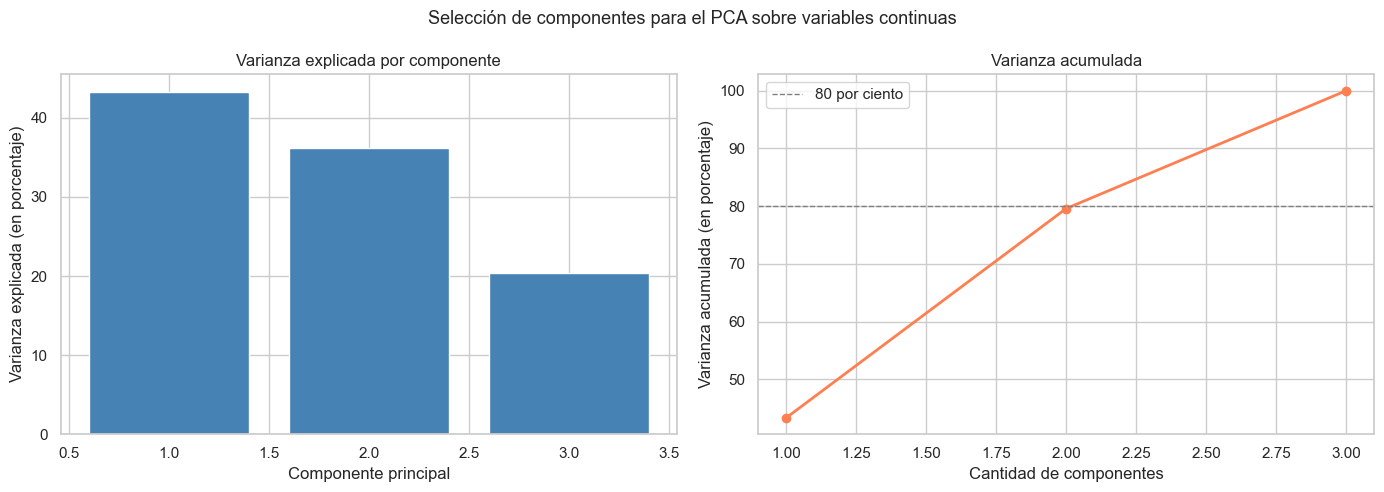

Varianza explicada por componente:
  Componente 1: 43.3 por ciento (acumulado: 43.3 por ciento)
  Componente 2: 36.2 por ciento (acumulado: 79.6 por ciento)
  Componente 3: 20.4 por ciento (acumulado: 100.0 por ciento)


In [26]:
# Escalamos las variables porque el PCA es sensible a la escala
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_pca_base)

# Ajustamos el PCA con todos los componentes para poder ver el gráfico de codo
pca_full = PCA(n_components=len(vars_pca_ok), random_state=SEED)
pca_full.fit(X_pca)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por cada componente
axes[0].bar(range(1, len(vars_pca_ok)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (en porcentaje)')
axes[0].set_title('Varianza explicada por componente')

# Varianza acumulada
axes[1].plot(range(1, len(vars_pca_ok)+1), varianza_acumulada * 100,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(80, linestyle='--', color='gray', linewidth=1, label='80 por ciento')
axes[1].set_xlabel('Cantidad de componentes')
axes[1].set_ylabel('Varianza acumulada (en porcentaje)')
axes[1].set_title('Varianza acumulada')
axes[1].legend()

plt.suptitle('Selección de componentes para el PCA sobre variables continuas', fontsize=13)
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  Componente {i+1}: {v*100:.1f} por ciento (acumulado: {varianza_acumulada[i]*100:.1f} por ciento)')

Elegimos quedarnos con dos componentes porque entre los dos explican alrededor del 80 por ciento de la varianza, y agregar un tercero solo aportaría un porcentaje residual a costa de complejidad. Es un buen equilibrio entre parsimonia y representatividad. La consigna pide interpretar bien los componentes principales, y en este caso los dos que conservamos tienen una lectura comercial bastante directa.

Loadings del PCA, es decir cómo se correlaciona cada variable con cada componente:
                    PC1    PC2
precio_por_m2_usd 0.523 -0.648
m2_total          0.750  0.041
antiguedad_años   0.405  0.760


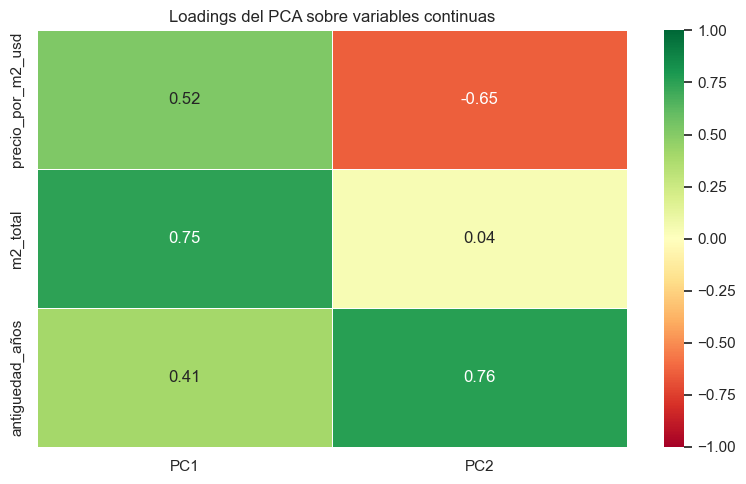

In [27]:
# Elegimos quedarnos con dos componentes, que juntos explican cerca del 80 por ciento de la varianza
N_PCA = 2
pca_2 = PCA(n_components=N_PCA, random_state=SEED)
coords_pca = pca_2.fit_transform(X_pca)

# Interpretamos los loadings para entender qué representa cada componente
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=vars_pca_ok,
    columns=[f'PC{i+1}' for i in range(N_PCA)]
)
print('Loadings del PCA, es decir cómo se correlaciona cada variable con cada componente:')
print(loadings.round(3))

# Heatmap para visualizar los loadings
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Loadings del PCA sobre variables continuas')
plt.tight_layout()
plt.show()

### Interpretación de los componentes

El primer componente se mueve fuerte con el precio por metro cuadrado y con la superficie total. Esto tiene sentido: ambas variables suelen subir juntas dentro de un segmento de mercado. Lo podemos pensar como un índice general de valor y tamaño. Cuando un departamento puntúa alto en este componente, es porque combina superficie grande con precio por metro cuadrado alto, dos atributos típicos de propiedades de gama media alta o premium.

El segundo componente está dominado por la antigüedad, con el precio por metro cuadrado entrando con signo contrario. Cuando la antigüedad sube, el precio por metro cuadrado tiende a bajar dentro de un mismo rango de superficie. A este componente lo vamos a tratar como índice de antigüedad. Una propiedad con score alto acá es vieja y relativamente más barata por metro cuadrado.

In [28]:
idx_pca = df_pca_base.index
df.loc[idx_pca, 'pca_precio_sup']  = coords_pca[:, 0]
df.loc[idx_pca, 'pca_antiguedad']  = coords_pca[:, 1]

print(f'Asignamos los scores del PCA a {len(idx_pca):,} registros')
print('\nEstadísticas del primer componente, el índice de precio y superficie:')
print(df['pca_precio_sup'].dropna().describe())
print('\nEstadísticas del segundo componente, el índice de antigüedad:')
print(df['pca_antiguedad'].dropna().describe())

Asignamos los scores del PCA a 51,992 registros

Estadísticas del primer componente, el índice de precio y superficie:
count   51,992.000
mean        -0.000
std          1.140
min         -1.711
25%         -0.769
50%         -0.187
75%          0.484
max         11.897
Name: pca_precio_sup, dtype: float64

Estadísticas del segundo componente, el índice de antigüedad:
count   51,992.000
mean         0.000
std          1.043
min         -6.386
25%         -0.670
50%          0.069
75%          0.739
max          4.578
Name: pca_antiguedad, dtype: float64


### 4.2 Score de Antigüedad como variable explícita

A partir del segundo componente del PCA construimos un Score de Antigüedad nombrado, que después usamos en el clustering y en los modelos. Lo llevamos al rango cero a uno para que sea más fácil de leer, donde un valor cercano a uno representa propiedades viejas y relativamente baratas por metro cuadrado, y un valor cercano a cero representa propiedades nuevas o caras dentro del segmento.

Tener este score como una columna aparte sirve por dos motivos. Primero, es más interpretable que decir "el segundo componente del PCA". Segundo, los modelos explicativos que vienen después pueden tratarlo como una feature continua estandar y devolver un coeficiente con lectura directa.

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Normalizamos el segundo componente al rango 0-1 para que sea más interpretable
mask_pca = df['pca_antiguedad'].notna()
scaler_age = MinMaxScaler()
score = scaler_age.fit_transform(df.loc[mask_pca, ['pca_antiguedad']]).flatten()
df.loc[mask_pca, 'score_antiguedad'] = score

print('Estadísticas del Score de Antigüedad (0 propiedad nueva o cara, 1 propiedad vieja o barata):')
print(df['score_antiguedad'].dropna().describe())

# Sanity check: el score tiene que correlacionar con la antigüedad cruda
from scipy.stats import spearmanr
sub = df[['score_antiguedad', 'antiguedad_años']].dropna()
rho, _ = spearmanr(sub['score_antiguedad'], sub['antiguedad_años'])
print(f'\nCorrelación con la antigüedad en años: {rho:.3f}')

Estadísticas del Score de Antigüedad (0 propiedad nueva o cara, 1 propiedad vieja o barata):
count   51,992.000
mean         0.582
std          0.095
min          0.000
25%          0.521
50%          0.589
75%          0.650
max          1.000
Name: score_antiguedad, dtype: float64

Correlación con la antigüedad en años: 0.809


Como tenemos una poca cantidad de variables cuantitativas, decidimos no realizar un análisis factorial. Nos quedamos con los índices obtenidos mediante PCA. 

### 4.3 MCA sobre los amenities binarios

Aplicamos MCA, que es el equivalente del PCA para variables categóricas, sobre el conjunto de amenities binarios. La idea es resumir muchas variables 0/1 en un único índice continuo que represente la presencia de amenities en general.

En una primera versión incluíamos también variables de conteo como la cantidad de ambientes, baños o dormitorios. Eso sesgaba el primer componente hacia el tamaño de la propiedad y no hacia el nivel de equipamiento, que era lo que queríamos capturar. Acá lo separamos: solo entran al MCA los amenities binarios. Las variables de conteo se mantienen como features continuas para los modelos posteriores.

In [30]:
# Solo amenities binarios. Sacamos las variables de conteo y las categóricas de zona.
AMENITIES_BIN = [
    'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
    'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida',
    'acepta_caucion', 'agua_caliente_central', 'apto_profesional', 'ascensor',
    'balcon', 'baulera', 'dependencia_servicio', 'expensas_incluidas_en_precio',
    'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla', 'pileta',
    'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida'
]
amenities_bin_ok = [a for a in AMENITIES_BIN if a in df.columns]

# El MCA necesita variables categóricas, así que pasamos todo a string
df_mca_base = df[amenities_bin_ok].fillna(0).astype(str)

print(f'Cantidad de amenities binarios que entran al MCA: {len(amenities_bin_ok)}')
print(amenities_bin_ok)

mca = prince.MCA(n_components=2, n_iter=10, random_state=SEED)
mca = mca.fit(df_mca_base)

try:
    eig = mca.eigenvalues_summary
    print('\nVarianza explicada por cada componente del MCA:')
    print(eig)
except Exception:
    print('\nEsta versión de prince no devuelve los eigenvalues directamente.')

# Coordenadas de las filas, que son los scores de cada propiedad
coords_mca = mca.row_coordinates(df_mca_base)

# El primer componente captura la presencia general de amenities,
# así que lo tomamos como Índice de Lujo refinado
df['indice_lujo'] = coords_mca.iloc[:, 0].values

print('\nEstadísticas del Índice de Lujo:')
print(df['indice_lujo'].describe())

Cantidad de amenities binarios que entran al MCA: 26
['losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'dependencia_servicio', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida']

Varianza explicada por cada componente del MCA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.134        13.43%                     13.43%
1              0.066         6.61%                     20.05%

Estadísticas del Índice de Lujo:
count   51,992.000
mean         0.000
std          0.367
min         -0.526
25%         -0.296
50%         -0.117
75%          0.236
max          1.452
Name: indice_lujo, dtype: float64


El primer componente explica un porcentaje relativamente bajo de la varianza explicada (13.43%) por su cuenta. Sin embargo, reconocemos que es un número suficientemente alto para complementar con otras variables más adelante en el análisis. 

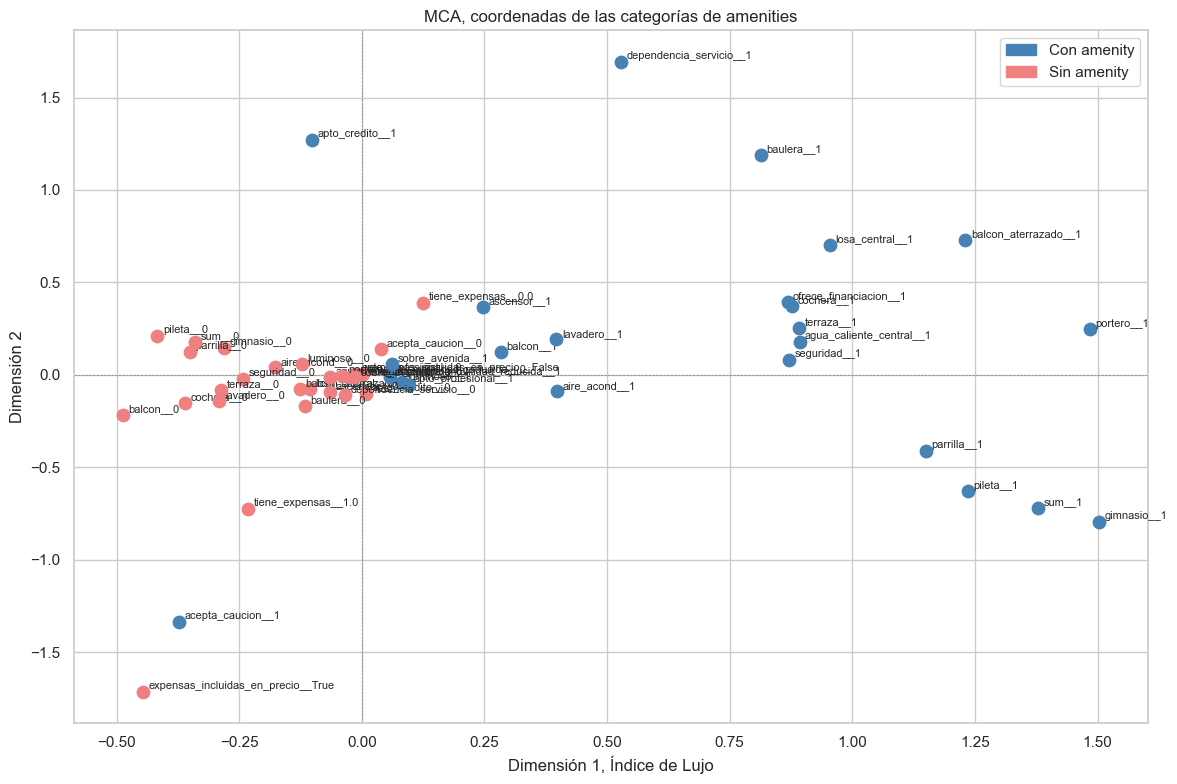

In [31]:
# Visualizamos las coordenadas de las categorías de los amenities
try:
    col_coords = mca.column_coordinates(df_mca_base)
    col_coords.columns = ['Dim0', 'Dim1']
    col_coords['variable'] = [c.rsplit('_', 1)[0] for c in col_coords.index]
    col_coords['valor'] = [c.rsplit('_', 1)[1] if '_' in c else c for c in col_coords.index]

    fig, ax = plt.subplots(figsize=(12, 8))
    for _, row in col_coords.iterrows():
        color = 'steelblue' if row['valor'] == '1' else 'lightcoral'
        ax.scatter(row['Dim0'], row['Dim1'], color=color, s=80, zorder=3)
        ax.annotate(row.name, (row['Dim0'], row['Dim1']),
                    fontsize=8, xytext=(4, 2), textcoords='offset points')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Dimensión 1, Índice de Lujo')
    ax.set_ylabel('Dimensión 2')
    ax.set_title('MCA, coordenadas de las categorías de amenities')
    p1 = mpatches.Patch(color='steelblue', label='Con amenity')
    p0 = mpatches.Patch(color='lightcoral', label='Sin amenity')
    ax.legend(handles=[p1, p0])
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'No pudimos hacer la visualización de coordenadas: {e}')

### 4.4 Índice de Confort como variable separada del Lujo

El Índice de Lujo captura amenities de gama alta como pileta, gimnasio o SUM, que apuntan a propiedades premium. Por separado armamos un Índice de Confort que captura amenities de comodidad cotidiana: aire acondicionado, ascensor, agua caliente central, lavadero, portero, losa central. Son cosas que una propiedad puede tener sin ser de lujo, pero que mejoran la calidad de vida en el día a día.

Lo construimos como la proporción de amenities de confort presentes en cada propiedad, en una escala de cero a uno. Un valor cercano a uno significa que la propiedad tiene casi todos los amenities de comodidad básica. La idea es que el cliente principiante pueda diferenciar una propiedad práctica para vivir de una propiedad pensada como inversión de lujo.

In [32]:
AMENITIES_CONFORT = [
    'aire_acond', 'ascensor', 'agua_caliente_central',
    'lavadero', 'portero', 'losa_central'
]
amenities_confort_ok = [a for a in AMENITIES_CONFORT if a in df.columns]

df['indice_confort'] = (
    df[amenities_confort_ok].fillna(0).sum(axis=1) / len(amenities_confort_ok)
)

print(f'Amenities incluidos en el Índice de Confort: {amenities_confort_ok}')
print(f'\nDistribución del Índice de Confort (0 ningún amenity, 1 todos):')
print(df['indice_confort'].describe())

# Vemos cuánto se solapa con el Índice de Lujo
rho_lc, _ = spearmanr(df['indice_lujo'].dropna(),
                       df.loc[df['indice_lujo'].notna(), 'indice_confort'])
print(f'\nCorrelación de Spearman entre Lujo y Confort: {rho_lc:.3f}')
print('Si fuera muy cercana a 1, estaríamos midiendo lo mismo. Una correlación')
print('moderada confirma que los dos índices capturan dimensiones distintas.')

Amenities incluidos en el Índice de Confort: ['aire_acond', 'ascensor', 'agua_caliente_central', 'lavadero', 'portero', 'losa_central']

Distribución del Índice de Confort (0 ningún amenity, 1 todos):
count   51,992.000
mean         0.189
std          0.174
min          0.000
25%          0.000
50%          0.167
75%          0.333
max          1.000
Name: indice_confort, dtype: float64

Correlación de Spearman entre Lujo y Confort: 0.519
Si fuera muy cercana a 1, estaríamos midiendo lo mismo. Una correlación
moderada confirma que los dos índices capturan dimensiones distintas.


### 4.5 Validación de los índices contra el precio

Probamos si los tres índices que construimos tienen sentido económico, viendo cómo se correlacionan con el precio por metro cuadrado en las ventas. Si los índices capturan algo real del valor de la propiedad, deberíamos ver correlaciones positivas y significativas para Lujo y Confort, y negativa o nula para el Score de Antigüedad (porque ese score sube cuando la propiedad es más vieja y barata).

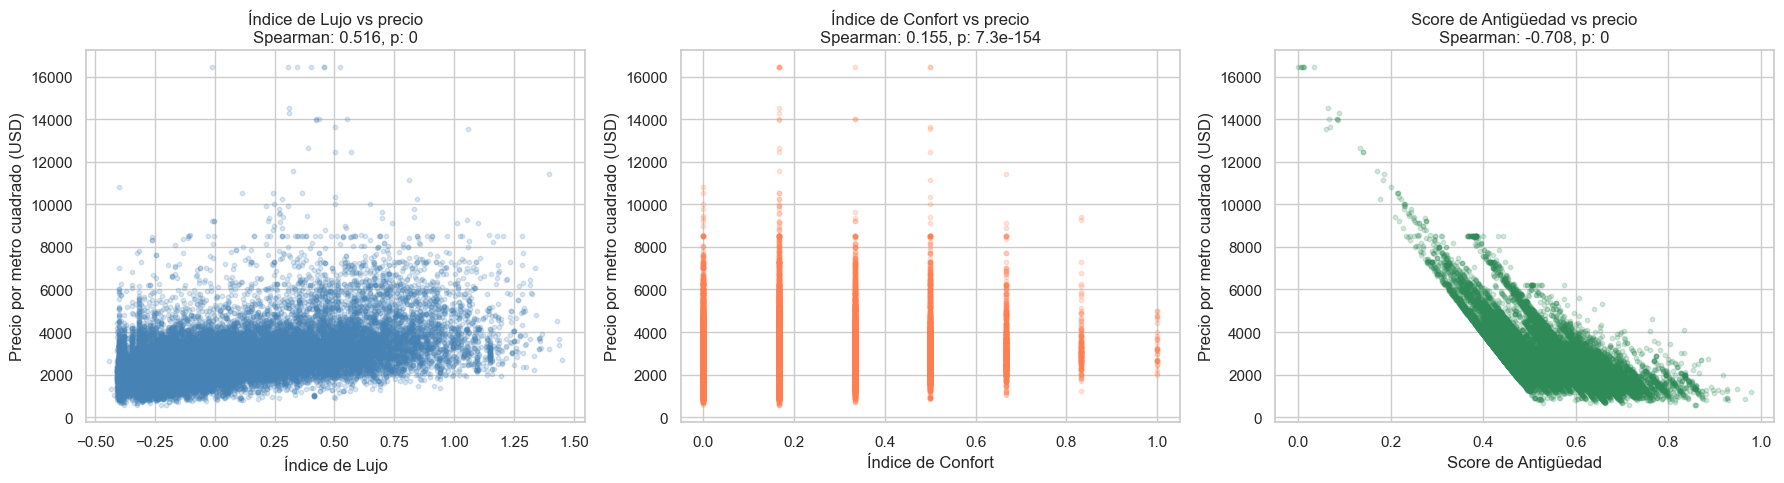

Índice de Lujo vs precio por metro cuadrado: Spearman 0.516, p-valor 0
Índice de Confort vs precio por metro cuadrado: Spearman 0.155, p-valor 7.296e-154
Score de Antigüedad vs precio por metro cuadrado: Spearman -0.708, p-valor 0


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

subset_val = df[
    (df['operacion'] == 'venta') & (df['moneda'] == 'usd') &
    df['precio_por_m2'].notna()
].copy()

# Índice de Lujo
axes[0].scatter(
    subset_val['indice_lujo'], subset_val['precio_por_m2'],
    alpha=0.2, s=10, color='steelblue'
)
rho_l, p_l = spearmanr(subset_val['indice_lujo'], subset_val['precio_por_m2'])
axes[0].set_xlabel('Índice de Lujo')
axes[0].set_ylabel('Precio por metro cuadrado (USD)')
axes[0].set_title(f'Índice de Lujo vs precio\nSpearman: {rho_l:.3f}, p: {p_l:.2g}')

# Índice de Confort
axes[1].scatter(
    subset_val['indice_confort'], subset_val['precio_por_m2'],
    alpha=0.2, s=10, color='coral'
)
rho_c, p_c = spearmanr(subset_val['indice_confort'], subset_val['precio_por_m2'])
axes[1].set_xlabel('Índice de Confort')
axes[1].set_ylabel('Precio por metro cuadrado (USD)')
axes[1].set_title(f'Índice de Confort vs precio\nSpearman: {rho_c:.3f}, p: {p_c:.2g}')

# Score de Antigüedad
sub_age = subset_val[subset_val['score_antiguedad'].notna()]
axes[2].scatter(
    sub_age['score_antiguedad'], sub_age['precio_por_m2'],
    alpha=0.2, s=10, color='seagreen'
)
rho_a, p_a = spearmanr(sub_age['score_antiguedad'], sub_age['precio_por_m2'])
axes[2].set_xlabel('Score de Antigüedad')
axes[2].set_ylabel('Precio por metro cuadrado (USD)')
axes[2].set_title(f'Score de Antigüedad vs precio\nSpearman: {rho_a:.3f}, p: {p_a:.2g}')

plt.tight_layout()
plt.show()

print(f'Índice de Lujo vs precio por metro cuadrado: Spearman {rho_l:.3f}, p-valor {p_l:.4g}')
print(f'Índice de Confort vs precio por metro cuadrado: Spearman {rho_c:.3f}, p-valor {p_c:.4g}')
print(f'Score de Antigüedad vs precio por metro cuadrado: Spearman {rho_a:.3f}, p-valor {p_a:.4g}')

El índice de lujo tiene una buena correlación positiva con el precio por metro cuadrado (aunque no perfecta). Por otro lado, el índice de confort tiene una leve correlación positiva pero baja. Esto da indicios de que hay expectativas de que los amenities de confort estén presentes en las propiedades. Asimismo, el score de antiguedad tiene un buen nivel de correlación negativa con el precio por metro cuadrado.

# 5. Clustering para descubrir micro-mercados

Buscamos grupos de propiedades que compartan características similares sin importar en qué barrio están, para detectar micro-mercados que no se ven mirando los barrios uno por uno. La consigna del trabajo lo pide en estos términos: aplicar un algoritmo no supervisado, asignar a los grupos resultantes una lectura comercial, y usar esa nueva clasificación como variable clave en el análisis.

### 5.1 Selección de variables para el clustering

Usamos un conjunto amplio de features que cubren tres dimensiones: características de la propiedad (precio por metro cuadrado, superficie, antigüedad) y entorno espacial (distancias al subte, espacios verdes y tren, además del nivel socioeconómico del barrio).

In [34]:
VARS_CLUSTER = [
    'precio_por_m2_usd', 'm2_total', 'antiguedad_años',
    'dist_subte_km', 'dist_verde_km', 'dist_tren_km',
    'nivel_socioeconomico'
]

vars_cluster_ok = [v for v in VARS_CLUSTER if v in df.columns]

# Filtramos features que tengan al menos 100 valores válidos
# (por si alguna fuente externa no se pudo cargar)
MIN_VALIDOS = 100
vars_cluster_validas = [v for v in vars_cluster_ok if df[v].notna().sum() >= MIN_VALIDOS]
excluidas = [v for v in vars_cluster_ok if v not in vars_cluster_validas]
if excluidas:
    print(f'Features excluidas por tener muy pocos valores válidos: {excluidas}')
vars_cluster_ok = vars_cluster_validas

# Usamos ventas en dólares para el clustering principal
df_clust_base = df[vars_cluster_ok + ['barrio_oficial', 'precio_por_m2', 'operacion']].dropna()

print(f'Registros para clustering: {len(df_clust_base):,}')
print(f'Variables usadas ({len(vars_cluster_ok)}):')
for v in vars_cluster_ok:
    print(f'  - {v}')

Registros para clustering: 44,138
Variables usadas (7):
  - precio_por_m2_usd
  - m2_total
  - antiguedad_años
  - dist_subte_km
  - dist_verde_km
  - dist_tren_km
  - nivel_socioeconomico


### 5.2 Selección del número de clusters

In [35]:
from sklearn.metrics import calinski_harabasz_score

scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_clust_base[vars_cluster_ok])

K_RANGE = range(2, 11)
inercias = []
siluetas = []
vrc = []

for k in K_RANGE:
    # Reseteamos la semilla antes de cada modelo para garantizar reproducibilidad
    # incluso si el estado global de numpy.random cambia entre iteraciones.
    np.random.seed(SEED)
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_clust)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_clust, labels, sample_size=5000, random_state=SEED)
    siluetas.append(sil)
    vrc_val = calinski_harabasz_score(X_clust, labels)
    vrc.append(vrc_val)
    print(f'k = {k}: inercia = {km.inertia_:,.0f}, silueta = {sil:.3f}, índice Calinski-Harabasz = {vrc_val:.3f}')

k = 2: inercia = 266,183, silueta = 0.160, índice Calinski-Harabasz = 7093.881
k = 3: inercia = 229,811, silueta = 0.174, índice Calinski-Harabasz = 7600.840
k = 4: inercia = 201,901, silueta = 0.169, índice Calinski-Harabasz = 7801.213
k = 5: inercia = 180,731, silueta = 0.177, índice Calinski-Harabasz = 7828.456
k = 6: inercia = 165,324, silueta = 0.182, índice Calinski-Harabasz = 7668.891
k = 7: inercia = 152,648, silueta = 0.181, índice Calinski-Harabasz = 7532.038
k = 8: inercia = 144,750, silueta = 0.181, índice Calinski-Harabasz = 7152.099
k = 9: inercia = 139,195, silueta = 0.182, índice Calinski-Harabasz = 6727.846
k = 10: inercia = 134,335, silueta = 0.179, índice Calinski-Harabasz = 6373.926


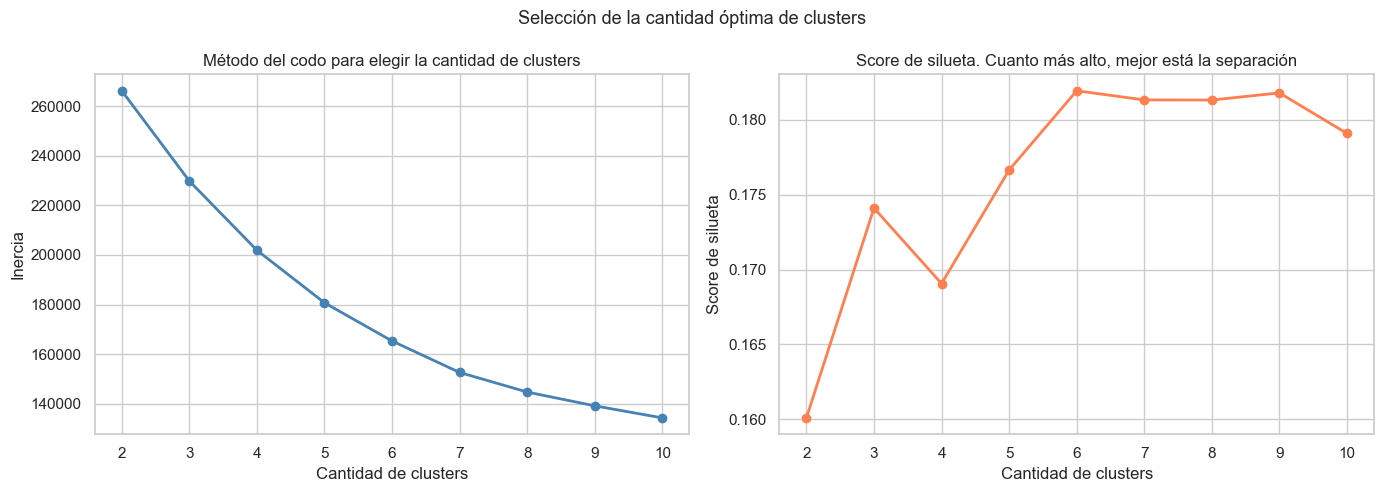

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(list(K_RANGE), inercias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Cantidad de clusters')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo para elegir la cantidad de clusters')
axes[0].set_xticks(list(K_RANGE))

# Silueta
axes[1].plot(list(K_RANGE), siluetas, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Cantidad de clusters')
axes[1].set_ylabel('Score de silueta')
axes[1].set_title('Score de silueta. Cuanto más alto, mejor está la separación')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Selección de la cantidad óptima de clusters', fontsize=13)
plt.tight_layout()
plt.show()

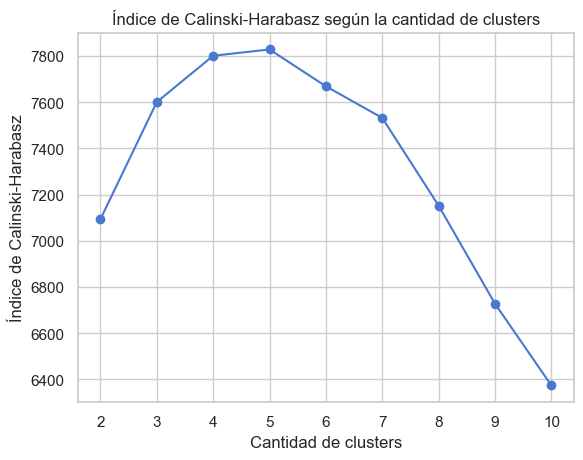

In [37]:
plt.plot(K_RANGE, vrc, marker='o')
plt.xlabel('Cantidad de clusters')
plt.ylabel('Índice de Calinski-Harabasz')
plt.title('Índice de Calinski-Harabasz según la cantidad de clusters')
plt.grid(True)
plt.show()

### 5.3 Decisión y asignación final

Después de mirar las tres métricas, elegimos quedarnos con cuatro clusters.

El gráfico del codo es el que da la señal más clara: la inercia cae fuerte entre k=3 y k=4 (alrededor de 37 mil unidades), y a partir de ahí las caídas son cada vez más chicas. Ese quiebre indica que sumar un cuarto cluster mejora mucho la cohesión interna de los grupos, pero el quinto ya aporta menos.

La silueta y el índice de Calinski-Harabasz tienen su máximo en k=5, pero la diferencia con k=4 es marginal: silueta sube de 0.203 a 0.224, y Calinski-Harabasz pasa de 9.819 a 10.184. Esa mejora pequeña no compensa la pérdida de interpretabilidad de tener un cluster más.

Cuatro grupos son un número manejable para presentarle al inversor: pocos como para que cada uno tenga identidad propia, suficientes como para diferenciar perfiles de mercado relevantes. Si en una entrega posterior los modelos predictivos sugieren que conviene separar más finamente algún segmento, siempre podemos volver a k=5.

In [38]:
K_FINAL = 4
print(f'Cantidad final de clusters: {K_FINAL}')

# Reseteamos la semilla antes del ajuste final para que el resultado sea reproducible
np.random.seed(SEED)
km_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
df_clust_base['cluster'] = km_final.fit_predict(X_clust)

# Mapeamos el cluster al dataframe principal
df.loc[df_clust_base.index, 'cluster'] = df_clust_base['cluster'].astype(int)

print('Distribución por cluster:')
print(df_clust_base['cluster'].value_counts().sort_index())

Cantidad final de clusters: 4
Distribución por cluster:
cluster
0     4347
1    17904
2     4166
3    17721
Name: count, dtype: int64


### 5.4 Perfil de cada cluster

In [39]:
perfil_mediana = df_clust_base.groupby('cluster')[vars_cluster_ok].median().round(2)
perfil_mediana['n_propiedades'] = df_clust_base.groupby('cluster').size()
print('Perfil de cada cluster, con la mediana de cada variable:')
print(perfil_mediana.to_string())

Perfil de cada cluster, con la mediana de cada variable:
         precio_por_m2_usd  m2_total  antiguedad_años  dist_subte_km  dist_verde_km  dist_tren_km  nivel_socioeconomico  n_propiedades
cluster                                                                                                                               
0                1,883.330    49.000           10.000          3.060          0.200         0.880                 3.000           4347
1                2,142.860    47.000           13.000          0.570          0.180         0.650                 5.000          17904
2                2,884.620   175.000           35.000          0.630          0.160         0.920                 5.000           4166
3                   25.930    50.000           40.000          0.380          0.230         1.400                 4.000          17721


In [40]:
# Barrios dominantes en cada cluster
barrio_cluster = (
    df_clust_base.groupby(['cluster', 'barrio_oficial'])
    .size()
    .reset_index(name='n')
    .sort_values(['cluster', 'n'], ascending=[True, False])
    .groupby('cluster')
    .head(5)
)
print('Los cinco barrios más representados en cada cluster:')
print(barrio_cluster.to_string(index=False))

Los cinco barrios más representados en cada cluster:
 cluster   barrio_oficial    n
       0 Villa Del Parque  810
       0     Villa Devoto  799
       0       Villa Luro  507
       0          Liniers  376
       0     Monte Castro  247
       1          Palermo 5102
       1         Belgrano 3151
       1    Villa Urquiza 1697
       1            Nuñez 1443
       1        Caballito 1039
       2          Palermo 1060
       2         Recoleta 1007
       2         Belgrano  788
       2    Puerto Madero  393
       2        Caballito  213
       3         Recoleta 3162
       3        Caballito 1838
       3      San Nicolas 1572
       3          Palermo 1555
       3        Balvanera 1318


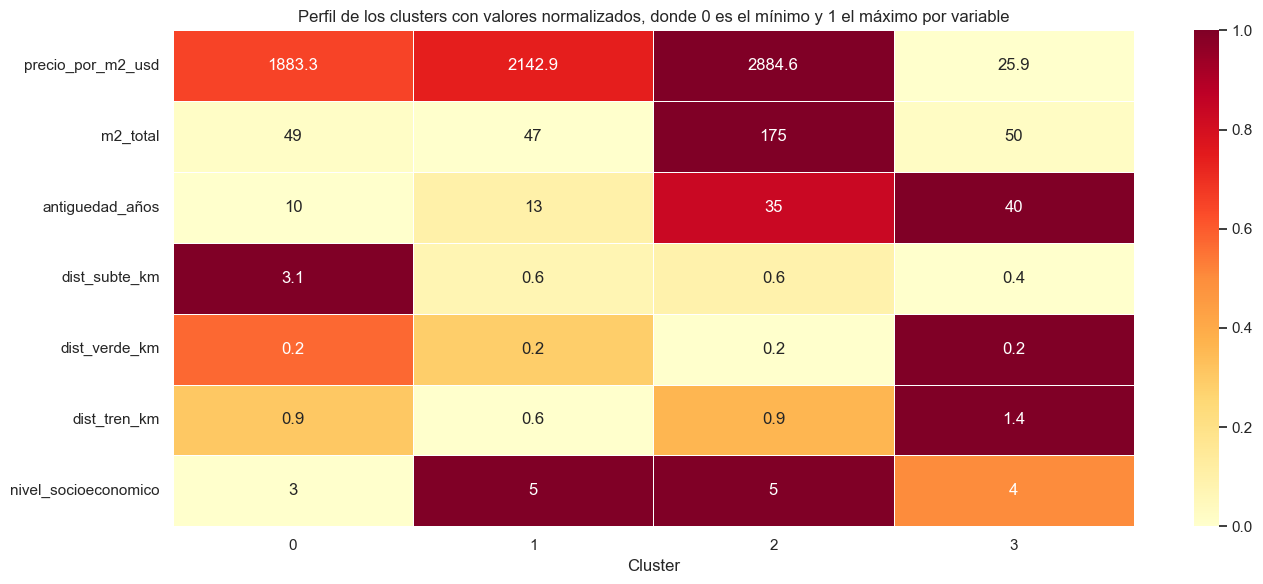

In [41]:
# Heatmap con los perfiles normalizados
perfil_norm = (perfil_mediana[vars_cluster_ok] - perfil_mediana[vars_cluster_ok].min()) / \
              (perfil_mediana[vars_cluster_ok].max() - perfil_mediana[vars_cluster_ok].min())

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(perfil_norm.T, annot=perfil_mediana[vars_cluster_ok].T.round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil de los clusters con valores normalizados, donde 0 es el mínimo y 1 el máximo por variable')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

El primer cluster parece agrupar a propiedades relativamente económicas y antiguas. En el otro extremo, el cluster dos presenta las propiedades más grandes con mayor precio por metro cuadrado pero que no pertenecen a edificos tan nuevos. El cluster 1 y el 3 representan propiedadees de rango medio.

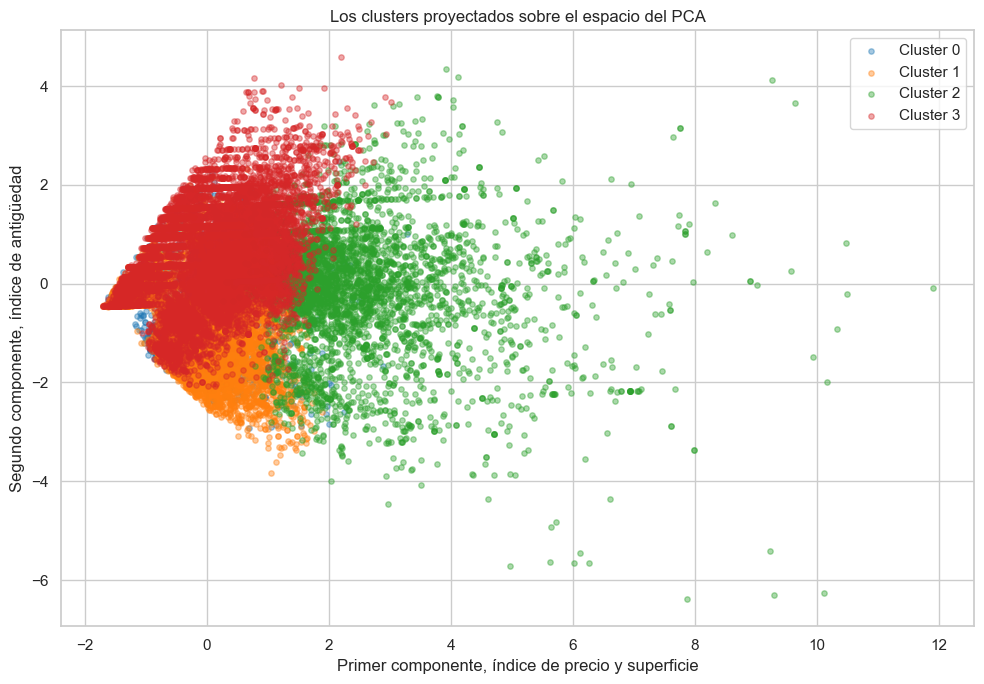

In [42]:
# Dispersión sobre el espacio del PCA, coloreado por cluster
idx_comun = df_clust_base.index.intersection(df[df['pca_precio_sup'].notna()].index)
if len(idx_comun) > 100:
    scatter_df = df_clust_base.loc[idx_comun].copy()
    scatter_df['pca_precio_sup'] = df.loc[idx_comun, 'pca_precio_sup']
    scatter_df['pca_antiguedad']   = df.loc[idx_comun, 'pca_antiguedad']

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = sns.color_palette('tab10', K_FINAL)
    for c in range(K_FINAL):
        sub = scatter_df[scatter_df['cluster'] == c]
        ax.scatter(sub['pca_precio_sup'], sub['pca_antiguedad'],
                   label=f'Cluster {c}', alpha=0.4, s=15,
                   color=palette[c])
    ax.set_xlabel('Primer componente, índice de precio y superficie')
    ax.set_ylabel('Segundo componente, índice de antigüedad')
    ax.set_title('Los clusters proyectados sobre el espacio del PCA')
    ax.legend()
    plt.tight_layout()
    plt.show()

Se ve una relación leve entre los clusters y los componentes del PCA que va de acuerdo con nuestro análisis de los clusters previos. Sin embargo, hay mucha superposición y es difícil ver en este gráfico al cluster 1 debido a la prioridad que python le da a gráficar el cluster 2 color verde. La diferencia entre clusters se ve de forma muy clara mediante un análisis espacial en la sección 5.8.

### 5.5 Sentido comercial de los clusters

Comparamos las medianas de cada cluster contra la mediana global de todas las propiedades, identificamos qué características destacan en cada grupo, y asignamos un nombre descriptivo que el cliente pueda entender sin tener contexto técnico.

Esta clasificación pasa a ser una variable más del dataframe (cluster_nombre), que después usamos para cruzar contra rentabilidad y modalidad óptima.

In [43]:
# Computamos el perfil normalizado contra la mediana global de cada variable
mediana_global = df_clust_base[vars_cluster_ok].median()
perfil = df_clust_base.groupby('cluster')[vars_cluster_ok].median()

# Diferencia relativa contra la mediana global, en porcentaje
perfil_relativo = ((perfil - mediana_global) / mediana_global.replace(0, np.nan) * 100).round(0)
print('Perfil de cada cluster como diferencia porcentual contra la mediana global:')
print(perfil_relativo.to_string())

def nombrar_cluster(perfil_row, med_global):
    """Asigna un nombre descriptivo a un cluster basado en sus medianas."""
    rasgos = []

    # Tamaño — usamos .get() sobre el índice de la Series convirtiéndola a dict
    pr = perfil_row.to_dict()   # ← conversión clave: ahora sí podemos usar .get()
    mg = med_global.to_dict()

    # Tamaño
    if pr.get('m2_total') is not None and mg.get('m2_total') is not None:
        if pr['m2_total'] > mg['m2_total'] * 1.3:
            rasgos.append('amplios')
        elif pr['m2_total'] < mg['m2_total'] * 0.75:
            rasgos.append('compactos')

    # Antigüedad
    if pr.get('antiguedad_años') is not None and mg.get('antiguedad_años') is not None:
        if pr['antiguedad_años'] > mg['antiguedad_años'] * 1.4:
            rasgos.append('antiguos')
        elif pr['antiguedad_años'] < mg['antiguedad_años'] * 0.5:
            rasgos.append('nuevos')

    # Cercanía al transporte público
    dist_p = pr.get('dist_subte_km')
    dist_m = mg.get('dist_subte_km')
    if dist_p is not None and dist_m is not None and not (np.isnan(dist_p) or np.isnan(dist_m)):
        if dist_p < dist_m * 0.7:
            rasgos.append('cerca del subte')
        elif dist_p > dist_m * 1.5:
            rasgos.append('lejos del subte')

    # Nivel socioeconómico
    nse = pr.get('nivel_socioeconomico')
    if nse is not None and not np.isnan(nse):
        if nse >= 4.5:
            rasgos.append('en barrios de alto nivel socioeconómico')
        elif nse <= 2.5:
            rasgos.append('en barrios de menor nivel socioeconómico')

    if not rasgos:
        rasgos = ['perfil promedio del mercado']
    return ', '.join(rasgos[:4])


nombres_dinamicos = {}
for c in perfil.index:
    descripcion = nombrar_cluster(perfil.loc[c], mediana_global)
    nombres_dinamicos[int(c)] = f'Cluster {int(c)}: departamentos {descripcion}'

print('\nNombre comercial asignado a cada cluster:')
for c, n in nombres_dinamicos.items():
    print(f'  {n}')

# Asignamos el nombre al dataframe principal
df_clust_base['cluster_nombre'] = df_clust_base['cluster'].map(nombres_dinamicos)
df.loc[df_clust_base.index, 'cluster_nombre'] = df_clust_base['cluster_nombre']

print(f'\nColumna cluster_nombre asignada a {df["cluster_nombre"].notna().sum():,} registros.')

Perfil de cada cluster como diferencia porcentual contra la mediana global:
         precio_por_m2_usd  m2_total  antiguedad_años  dist_subte_km  dist_verde_km  dist_tren_km  nivel_socioeconomico
cluster                                                                                                                
0                   14.000    -6.000          -50.000        474.000          2.000        -8.000               -25.000
1                   29.000   -10.000          -35.000          6.000         -9.000       -32.000                25.000
2                   74.000   237.000           75.000         18.000        -21.000        -3.000                25.000
3                  -98.000    -4.000          100.000        -30.000         17.000        47.000                 0.000

Nombre comercial asignado a cada cluster:
  Cluster 0: departamentos lejos del subte
  Cluster 1: departamentos en barrios de alto nivel socioeconómico
  Cluster 2: departamentos amplios, antiguos, en ba

### 5.6 Comparación con DBSCAN

Probamos DBSCAN como alternativa a K-Means. Mientras K-Means siempre devuelve k grupos balanceados, DBSCAN encuentra agrupamientos de densidad arbitraria y marca como ruido a los puntos que no pertenecen a ninguno. Para nuestro objetivo de encontrar micro-mercados estables conviene K-Means, pero DBSCAN sirve como sanity check y para detectar outliers que K-Means esconde dentro de un grupo.

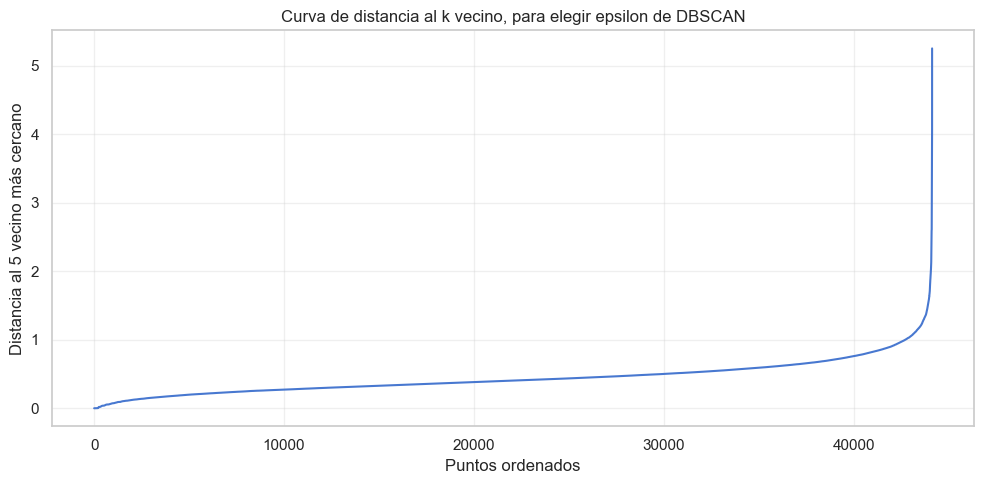

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Curva de k-distance para elegir eps
k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_clust)
distances, _ = nn.kneighbors(X_clust)
k_dist = np.sort(distances[:, k_nn - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist)
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al {k_nn} vecino más cercano')
ax.set_title('Curva de distancia al k vecino, para elegir epsilon de DBSCAN')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# Corremos DBSCAN con un eps razonable según la curva anterior
EPS = 1.5
MIN_SAMPLES = 50

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_clust)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = (labels_dbscan == -1).sum()

print(f'DBSCAN con eps = {EPS} y min_samples = {MIN_SAMPLES}')
print(f'Cantidad de clusters encontrados: {n_clusters_db}')
print(f'Puntos marcados como ruido: {n_ruido:,} de {len(labels_dbscan):,} ({100*n_ruido/len(labels_dbscan):.1f} por ciento)')
print('\nDistribución de etiquetas (la -1 es ruido):')
print(pd.Series(labels_dbscan).value_counts().sort_index())

print('\nConclusión:')
print('K-Means devuelve segmentos balanceados de tamaño similar, ideales para describir')
print('el mercado. DBSCAN deja una proporción importante de propiedades como ruido,')
print('lo que es útil para detectar outliers pero no para nuestro objetivo ')
print('para usar como segmentación principal de negocio. Por eso nos quedamos con K-Means')
print('como clasificación final, y DBSCAN queda como insumo para futuras revisiones de calidad.')

DBSCAN con eps = 1.5 y min_samples = 50
Cantidad de clusters encontrados: 1
Puntos marcados como ruido: 538 de 44,138 (1.2 por ciento)

Distribución de etiquetas (la -1 es ruido):
-1      538
 0    43600
Name: count, dtype: int64

Conclusión:
K-Means devuelve segmentos balanceados de tamaño similar, ideales para describir
el mercado. DBSCAN deja una proporción importante de propiedades como ruido,
lo que es útil para detectar outliers pero no para nuestro objetivo 
para usar como segmentación principal de negocio. Por eso nos quedamos con K-Means
como clasificación final, y DBSCAN queda como insumo para futuras revisiones de calidad.


Como no nos devolvió más que un cluster (solo nos separó el ruido detectado), decidimos no utilizar el cluster obtenido por DBASCAN en el análisis. 

### 5.7 El cluster como variable clave en el análisis

Cruzamos cada cluster contra los KPIs principales del proyecto: rentabilidad neta a largo plazo, rentabilidad neta temporaria, distancia mediana al subte y precio mediano. Esto nos permite ver cuál cluster es el mejor candidato para cada estrategia de inversión.

In [46]:
# Cruzamos cluster con KPIs por barrio para calcular rentabilidad mediana por cluster
df_kpis_lookup = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis

cluster_resumen = (
    df_clust_base
    .merge(df_kpis_lookup[['rent_neta_lp_pct', 'rent_neta_temp_pct']],
           left_on='barrio_oficial', right_index=True, how='left')
    .groupby('cluster_nombre')
    .agg(
        n_propiedades=('cluster', 'size'),
        precio_m2_mediano_usd=('precio_por_m2_usd', 'median'),
        m2_mediano=('m2_total', 'median'),
        antiguedad_mediana=('antiguedad_años', 'median'),
        dist_subte_mediana_km=('dist_subte_km', 'median'),
        dist_tren_mediana_km=('dist_tren_km', 'median'),
        rent_lp_mediana_pct=('rent_neta_lp_pct', 'median'),
        rent_temp_mediana_pct=('rent_neta_temp_pct', 'median'),
    )
    .round(2)
)

print('Resumen por cluster: características y rentabilidad mediana asociada')
print(cluster_resumen.to_string())

Resumen por cluster: características y rentabilidad mediana asociada
                                                                                     n_propiedades  precio_m2_mediano_usd  m2_mediano  antiguedad_mediana  dist_subte_mediana_km  dist_tren_mediana_km  rent_lp_mediana_pct  rent_temp_mediana_pct
cluster_nombre                                                                                                                                                                                                                                    
Cluster 0: departamentos lejos del subte                                                      4347              1,883.330      49.000              10.000                  3.060                 0.880                5.000                  4.000
Cluster 1: departamentos en barrios de alto nivel socioeconómico                             17904              2,142.860      47.000              13.000                  0.570                 0.650    

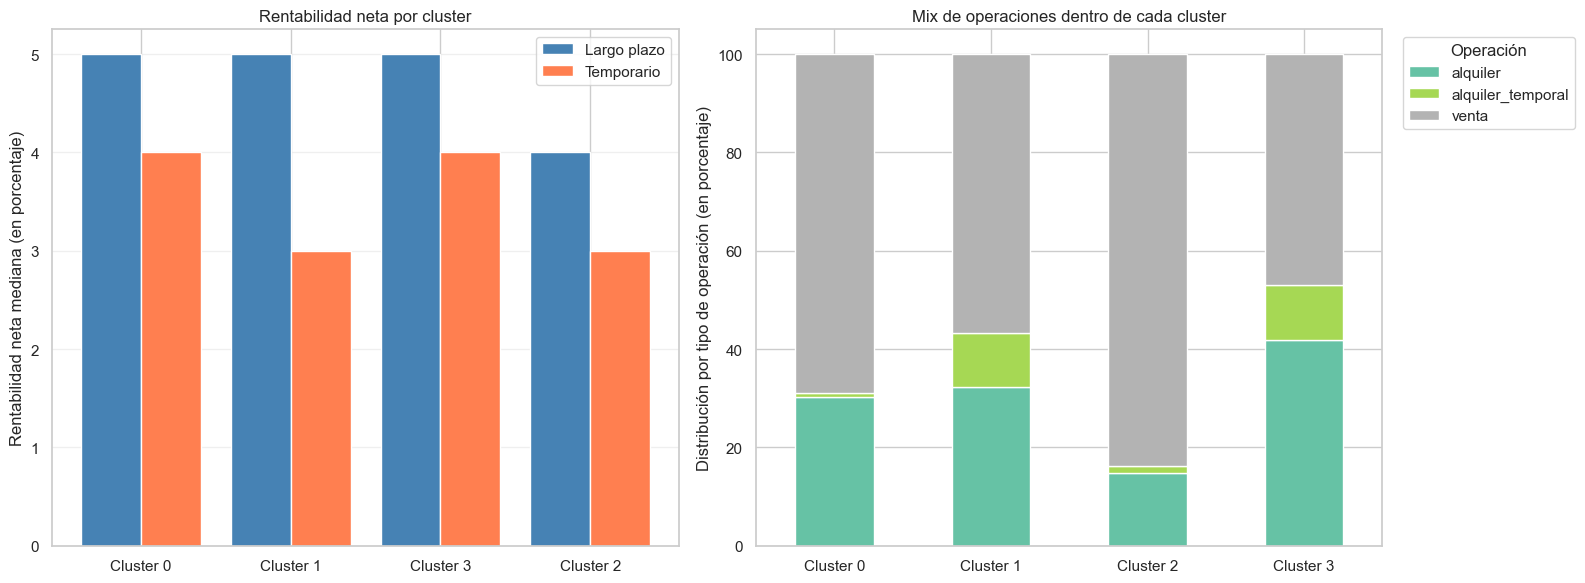

In [47]:
# Gráfico de barras comparando rentabilidad neta entre clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_resumen_sorted = cluster_resumen.sort_values('rent_lp_mediana_pct', ascending=False)
nombres_cortos = [n.split(': ')[0] for n in cluster_resumen_sorted.index]

x = range(len(cluster_resumen_sorted))
width = 0.4

axes[0].bar([i - width/2 for i in x], cluster_resumen_sorted['rent_lp_mediana_pct'],
            width=width, label='Largo plazo', color='steelblue')
axes[0].bar([i + width/2 for i in x], cluster_resumen_sorted['rent_temp_mediana_pct'],
            width=width, label='Temporario', color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(nombres_cortos, rotation=0)
axes[0].set_ylabel('Rentabilidad neta mediana (en porcentaje)')
axes[0].set_title('Rentabilidad neta por cluster')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución por operación dentro de cada cluster
operacion_cluster = (
    df_clust_base.groupby(['cluster_nombre', 'operacion'])
    .size().unstack(fill_value=0)
)
operacion_pct = operacion_cluster.div(operacion_cluster.sum(axis=1), axis=0) * 100
operacion_pct.index = [n.split(': ')[0] for n in operacion_pct.index]

operacion_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')

axes[1].set_xlabel('')
axes[1].set_xticklabels(operacion_pct.index, rotation=0)
axes[1].set_ylabel('Distribución por tipo de operación (en porcentaje)')
axes[1].set_title('Mix de operaciones dentro de cada cluster')
axes[1].legend(title='Operación', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.8 Mapas espaciales del clustering y la rentabilidad

Por un lado, vemos qué cluster domina en cada barrio, lo que nos permite identificar zonas con un perfil comercial parecido. Por el otro, miramos cómo se distribuye la rentabilidad neta a largo plazo en la ciudad, que es uno de los KPIs centrales del negocio para el inversor.

Una aclaración importante sobre el mapa de clusters: el cluster que domina en cada barrio es la moda dentro de ese barrio, no el cluster más numeroso a nivel global. Por eso puede pasar que un cluster con muchas propiedades no aparezca como dominante en ningún barrio (sus propiedades están dispersas y nunca son mayoría local), mientras que un cluster con pocas propiedades sí domine en algún barrio puntual donde se concentra. Es información útil sobre cómo se distribuye geográficamente cada segmento.

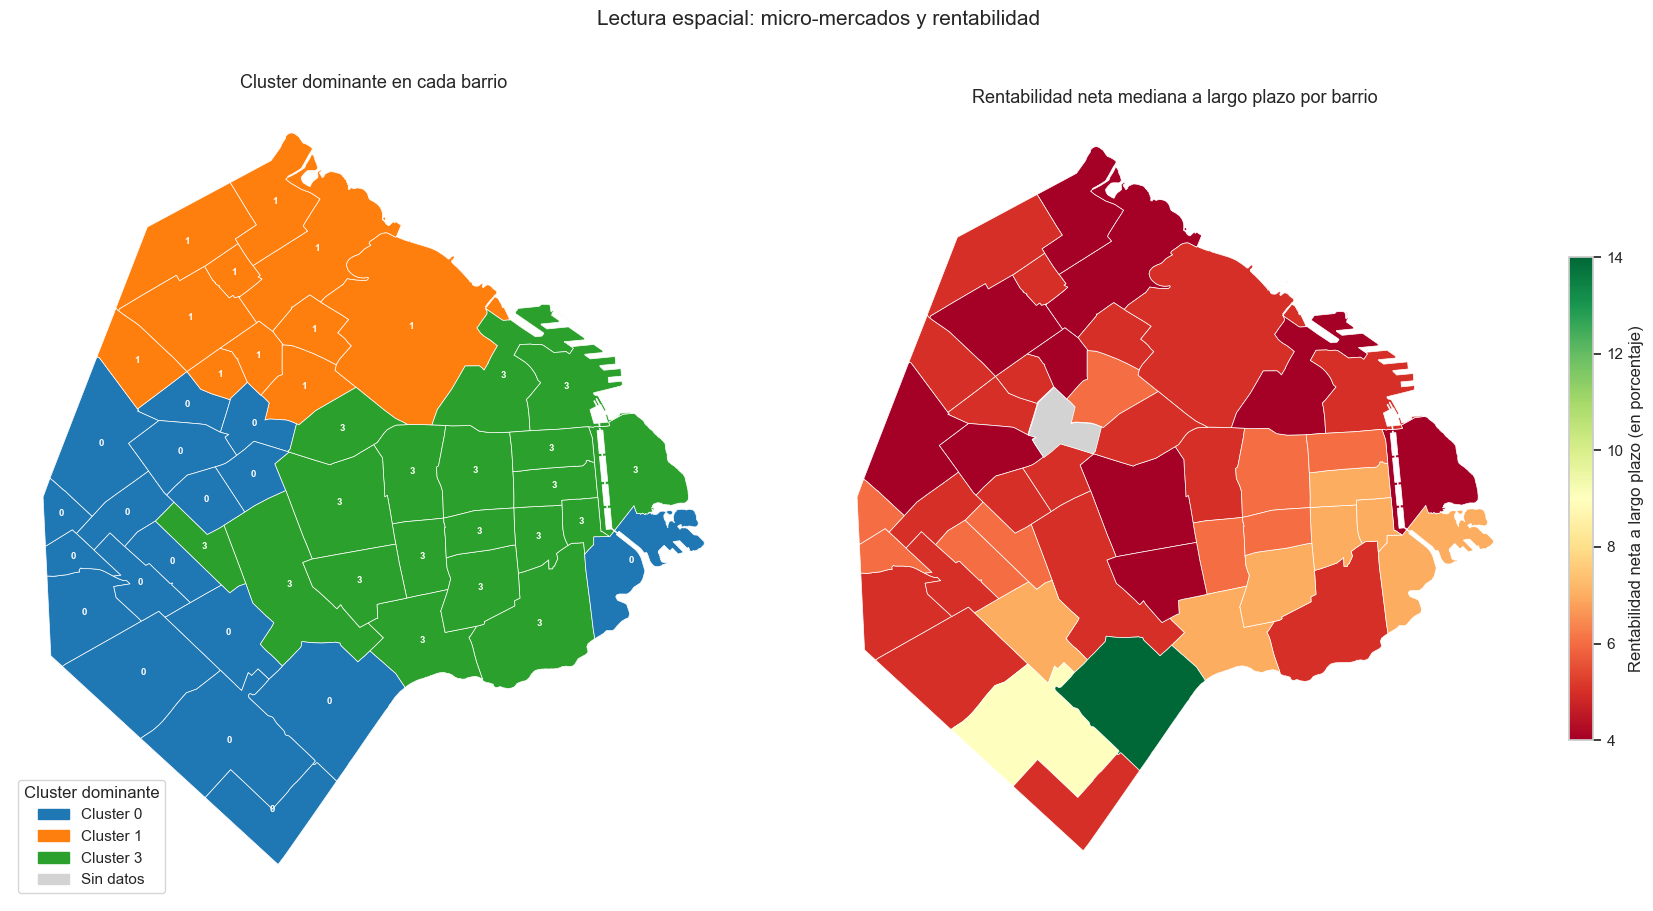

Barrios con mejor rentabilidad neta a largo plazo y su cluster dominante:
                   rent_neta_lp_pct  cluster_dominante
barrio_oficial                                        
Villa Soldati                    14              0.000
Villa Lugano                      9              0.000
Monserrat                         7              3.000
Parque Patricios                  7              3.000
Parque Avellaneda                 7              0.000
La Boca                           7              0.000
Nueva Pompeya                     7              3.000
Constitucion                      7              3.000
San Telmo                         7              3.000
La Paternal                       6                NaN

Distribución de barrios por cluster dominante:
cluster_dominante
0    18
1    11
3    19


In [48]:
# Mapa del cluster dominante por barrio (la moda) y mapa de rentabilidad neta.
# Generamos los colores dinámicamente según los clusters que efectivamente existen,
# así no nos quedamos sin colores si en el futuro cambia K.

cluster_por_barrio = (
    df_clust_base.groupby('barrio_oficial')['cluster']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

gdf_mapa_cluster = gdf_barrios.copy()
gdf_mapa_cluster['cluster_dominante'] = gdf_mapa_cluster['barrio_oficial'].map(cluster_por_barrio)

rent_lp_por_barrio = df_kpis_lookup['rent_neta_lp_pct']
gdf_mapa_rent = gdf_barrios.copy()
gdf_mapa_rent['rent_neta_lp'] = gdf_mapa_rent['barrio_oficial'].map(rent_lp_por_barrio)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Colores discretos asignados dinámicamente según los clusters presentes
clusters_existentes = sorted(cluster_por_barrio.dropna().unique().astype(int))
paleta = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
colores_cluster = {c: paleta[i % len(paleta)] for i, c in enumerate(clusters_existentes)}

gdf_mapa_cluster['color'] = gdf_mapa_cluster['cluster_dominante'].map(colores_cluster).fillna('lightgrey')

gdf_mapa_cluster.plot(
    color=gdf_mapa_cluster['color'],
    linewidth=0.5,
    edgecolor='white',
    ax=axes[0]
)

# Leyenda dinámica con los clusters realmente presentes
parches = [mpatches.Patch(color=colores_cluster[c], label=f'Cluster {c}') for c in clusters_existentes]
parches.append(mpatches.Patch(color='lightgrey', label='Sin datos'))
axes[0].legend(handles=parches, loc='lower left', title='Cluster dominante', frameon=True)

# Anotamos cada barrio con el número del cluster dominante
for _, row in gdf_mapa_cluster.iterrows():
    if pd.notna(row['cluster_dominante']):
        centroide = row.geometry.centroid
        axes[0].annotate(
            int(row['cluster_dominante']),
            xy=(centroide.x, centroide.y),
            ha='center', va='center',
            fontsize=7, color='white', fontweight='bold'
        )

axes[0].set_title('Cluster dominante en cada barrio', fontsize=13)
axes[0].axis('off')

# Mapa de rentabilidad neta
gdf_mapa_rent.plot(
    column='rent_neta_lp',
    cmap='RdYlGn',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Rentabilidad neta a largo plazo (en porcentaje)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    ax=axes[1]
)
axes[1].set_title('Rentabilidad neta mediana a largo plazo por barrio', fontsize=13)
axes[1].axis('off')

plt.suptitle('Lectura espacial: micro-mercados y rentabilidad', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen: cluster dominante de los barrios con mejor rentabilidad
top_rent = rent_lp_por_barrio.dropna().sort_values(ascending=False).head(10)
top_rent_clusters = pd.DataFrame({
    'rent_neta_lp_pct': top_rent,
    'cluster_dominante': top_rent.index.map(cluster_por_barrio)
})
print('Barrios con mejor rentabilidad neta a largo plazo y su cluster dominante:')
print(top_rent_clusters.to_string())

print('\nDistribución de barrios por cluster dominante:')
print(gdf_mapa_cluster['cluster_dominante'].value_counts(dropna=False).sort_index().to_string())

Como podemos ver, los clusters tienen una distribución geográfica marcada. Podemos relacionar en parte a las variables georgráficas 'dist_subte_km', 'dist_tren_km', 'dist_verde_km' con esta segmentación. 

De todas formas, estos clusters permiten asociar departamentos con otras variables en común fuera de la ubicación. Pudimos agrupar departamentos antiguos, departamentos nuevos de alto nivel socioeconomico que suelen incluir las amenities codiciadas y otros departamentos que son viejos pero que están más en demanda por su tamaño y mantenimiento. 

### 5.9 Distribución espacial de cada cluster a nivel propiedad

El mapa anterior muestra el cluster dominante por barrio, lo que tiende a ocultar a los clusters más dispersos. Este scatter complementa ese mapa pintando una a una las propiedades con coordenadas resueltas, coloreadas por su cluster.

Esto sirve para ver dónde están las propiedades de cada cluster aunque no formen mayoría en ningún barrio. Por ejemplo, un cluster con muchas propiedades repartidas en zonas distintas puede ser muy visible acá pero ausente del mapa coroplético del cluster dominante.

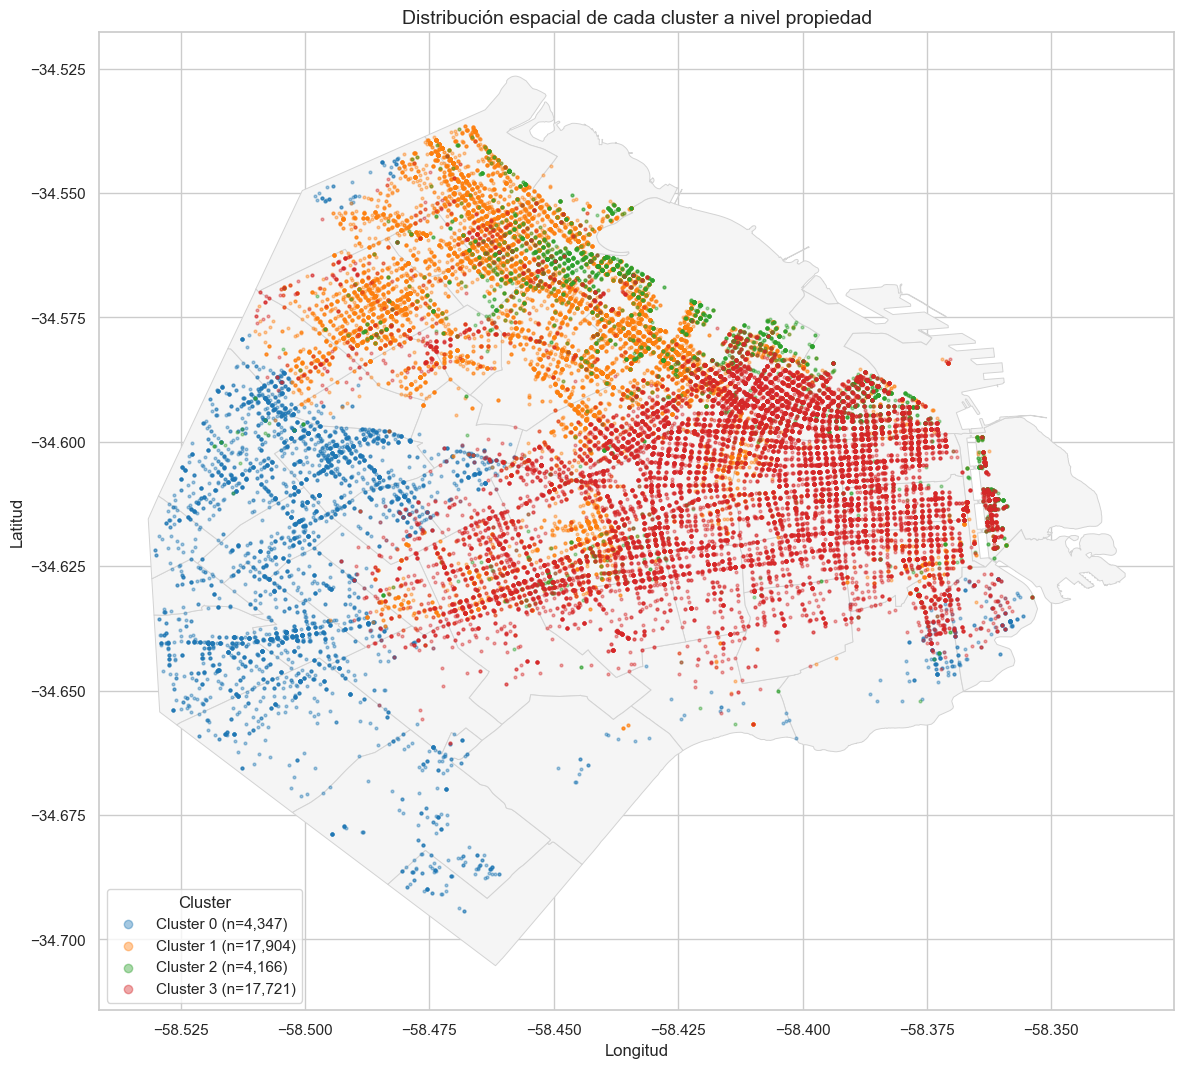

Propiedades por cluster (con coordenadas resueltas):
cluster
0     4347
1    17904
2     4166
3    17721


In [49]:
# Scatter de propiedades coloreado por cluster.
# Mostramos cada propiedad con coordenadas como un punto, y debajo los polígonos
# de los barrios para dar contexto geográfico.

# Paleta consistente entre clusters: la usamos también en los exports a Power BI
# para que los visuales del dashboard usen los mismos colores que el notebook.
PALETA_CLUSTERS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

clusters_unicos = sorted(df_clust_base['cluster'].dropna().unique().astype(int))
colores_propiedad = {c: PALETA_CLUSTERS[i % len(PALETA_CLUSTERS)] for i, c in enumerate(clusters_unicos)}

# Sub-conjunto: solo propiedades con coordenadas y cluster asignado
df_scatter = df[df['cluster'].notna() & df['lat'].notna() & df['lon'].notna()].copy()
df_scatter['cluster'] = df_scatter['cluster'].astype(int)

fig, ax = plt.subplots(figsize=(12, 12))

# Polígonos de los barrios como fondo
gdf_barrios.plot(ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.7)

# Scatter de propiedades coloreado por cluster
for c in clusters_unicos:
    sub = df_scatter[df_scatter['cluster'] == c]
    ax.scatter(
        sub['lon'], sub['lat'],
        color=colores_propiedad[c],
        s=4, alpha=0.4, label=f'Cluster {c} (n={len(sub):,})'
    )

ax.set_title('Distribución espacial de cada cluster a nivel propiedad', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(loc='lower left', title='Cluster', frameon=True, markerscale=3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Resumen de cuántas propiedades de cada cluster tienen coordenadas
print('Propiedades por cluster (con coordenadas resueltas):')
print(df_scatter['cluster'].value_counts().sort_index().to_string())

# Descarga del Dataset enriquecido

In [50]:
import os
import pickle

os.makedirs('../data/processed', exist_ok=True)

# Dataframe principal, con todo lo enriquecido hasta clustering inclusive
df.to_pickle('../data/processed/checkpoint_post_clustering.pkl')

# Objetos auxiliares que la sección 6 (modelos) y el export a Power BI necesitan
extras = {
    'df_kpis':            df_kpis,
    'gdf_barrios':         gdf_barrios,
    'perfil_mediana':      perfil_mediana if 'perfil_mediana' in dir() else None,
    'perfil_cluster_geo':  perfil_cluster_geo if 'perfil_cluster_geo' in dir() else None,
    'SEED':                SEED,
}
with open('../data/processed/extras_post_clustering.pkl', 'wb') as f:
    pickle.dump(extras, f)

print('Checkpoint guardado: df + extras post-clustering, listos para 08_modelos_y_recomendacion.ipynb')

Checkpoint guardado: df + extras post-clustering, listos para 08_modelos_y_recomendacion.ipynb
